# Settings

In [ ]:
library(dplyr)
library(stringr)
library(tidyr)
library(Seurat)
library(Signac)
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(qs)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.3”


# Create meta data

In [4]:
#adata <- qread('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.qs')
#adata

An object of class Seurat 
70217 features across 181892 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap

In [19]:
hep.sub.meta <- select(adata[[]], donor=Donor, Batch, Target, predicted.celltype, predicted.cellsubtype)  %>%
    filter(Target == 'H3K27me3' & predicted.celltype=='Hepatocytes') %>%
    select(-Target, -predicted.celltype) %>% 
    group_by(predicted.cellsubtype, donor) %>%
    summarise(count=n()) %>%
    pivot_wider(names_from = predicted.cellsubtype, values_from = count, values_fill = 0)

hep.sub.meta

`summarise()` has grouped output by 'predicted.cellsubtype'. You can override using the `.groups` argument.


donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,10,1,34,365,104
HL150009,10,2,33,521,147
HL150013,24,1,32,122,65
HL150015,6,9,82,1070,234
HL160017,25,1668,0,35,30
HL160022,140,7,5,3,3
HL160026,311,8,178,707,138
HL160029,3,24,571,33,87
HL160030,9,0,40,639,394


In [16]:
meta.ct = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/08_H3K27ac_DESEQ/H3K27ac.meta.tsv", 
                  sep='\t', header=T)
meta.ct$Age.scaled = scale(meta.ct$Age)
meta.ct$BMI.scaled = scale(meta.ct$BMI)
colnames(meta.ct)
meta.ct$donor <- meta.ct$donor_demux

#meta.ct$HF_status = meta.ct$disease_status
meta.ct

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>
1,HL150001,12,17,58,534,15,1,78,10,0,⋯,0,Centrizonal,0,0,0,0,1,M,47,27.1
2,HL150009,3,11,104,761,116,0,65,17,3,⋯,0,centrizonal,0,0,0,0,1,M,37,29.4


[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "Age.scaled"           "BMI.scaled"

donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,Age.scaled,BMI.scaled,donor
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<chr>
HL150001,12,17,58,534,15,1,78,10,0,⋯,0,0,0,1,M,47,27.10,-0.01553551,-0.638584666,HL150001
HL150009,3,11,104,761,116,0,65,17,3,⋯,0,0,0,1,M,37,29.40,-0.75778750,-0.334686949,HL150009
HL150013,22,37,112,281,77,4,100,20,0,⋯,1,1-2 Mild/moderate,Spotty,3,M,45,35.00,-0.16398591,0.405237926,HL150013
HL150015,12,69,89,1266,66,0,59,15,0,⋯,0,1,0,3,M,59,29.10,0.87516689,-0.374325782,HL150015
HL160017,10,32,71,1476,26,0,234,10,1,⋯,0,2,0,2,M,31,24.00,-1.20313870,-1.048185936,HL160017
HL160022,0,129,45,131,28,0,50,0,2,⋯,1,1,0,5,F,45,29.80,-0.16398591,-0.281835172,HL160022
HL160026,2,18,162,959,105,0,19,7,0,⋯,0,0,Spotty,0,F,25,26.00,-1.64848990,-0.783927052,HL160026
HL160029,19,117,415,861,154,0,191,45,2,⋯,0,0,0,0,F,47,30.86,-0.01553551,-0.141777964,HL160029
HL160030,7,59,228,997,55,0,50,12,3,⋯,0,0,0,2,M,29,30.20,-1.35158910,-0.228983396,HL160030


In [81]:
meta = select(meta.ct, -B, -Cholangiocyte, -Endothelial, -Hepatocytes, -HSC,
      -Mast, -Myeloid, -NK, -Schwann, -T) %>% full_join(hep.sub.meta)
meta

Joining with `by = join_by(donor)`


donor_demux,batch,disease_status,condition,Steatosis.grade,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,⋯,Age,BMI,Age.scaled,BMI.scaled,donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,⋯,<int>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,2262024,Disease,MASL,1,0,Centrizonal,0,0,0,⋯,47,27.10,-0.01553551,-0.638584666,HL150001,10,1,34,365,104
HL150009,2262024,Disease,MASL,1,0,centrizonal,0,0,0,⋯,37,29.40,-0.75778750,-0.334686949,HL150009,10,2,33,521,147
HL150013,10252023,Disease,MASH,1,2,"Centrilobular, Diffuse",1,1,1-2 Mild/moderate,⋯,45,35.00,-0.16398591,0.405237926,HL150013,24,1,32,122,65
HL150015,2262024,Disease,MASL,3,1,"Centrilobular, Diffuse",0,0,1,⋯,59,29.10,0.87516689,-0.374325782,HL150015,6,9,82,1070,234
HL160017,2262024,Disease,MetALD,1,2,Centrilobular,1,0,2,⋯,31,24.00,-1.20313870,-1.048185936,HL160017,25,1668,0,35,30
HL160022,10252023,Disease,MASH,3,2,Diffuse,1,1,1,⋯,45,29.80,-0.16398591,-0.281835172,HL160022,140,7,5,3,3
HL160026,2262024,Control,Control,0,0,0,0,0,0,⋯,25,26.00,-1.64848990,-0.783927052,HL160026,311,8,178,707,138
HL160029,8012023,Control,Control,0,0,<5%,0,0,0,⋯,47,30.86,-0.01553551,-0.141777964,HL160029,3,24,571,33,87
HL160030,10252023,Disease,MASL,2,0,N/A,0,0,0,⋯,29,30.20,-1.35158910,-0.228983396,HL160030,9,0,40,639,394


In [82]:
write.table(meta, '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/H3K27ac_Hep_Subtypes.DESeq.meta.data.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')

# Split counts

In [58]:
count.full <- vroom::vroom('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/FNIH_Liver_pool.H3K27ac_cellsubtype_fib_donor.LiverUnionPeaks.rpm.csv',
                        delim=',')
colnames(count.full)[1] <- 'peaks'
count.full <- tibble::column_to_rownames(count.full, var='peaks')

dim(count.full)
head(count.full)
gc()

New names:
• `` -> `...1`
Rows: 612056 Columns: 1563
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (1562): HL150001:Activated.HSC:MASL, HL150001:B:MASL, HL150001:Cholangio...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 612056   1562

,HL150001:Activated.HSC:MASL,HL150001:B:MASL,HL150001:Cholangiocyte:MASL,HL150001:Hepatocytes.Senescent:MASL,HL150001:Hepatocytes.Zone1:MASL,HL150001:Hepatocytes.Zone2:MASL,HL150001:Hepatocytes.Zone3:MASL,HL150001:Kupffer:MASL,HL150001:Macrophage:MASL,HL150001:Mast:MASL,⋯,HL230325:Lipid.Associated.Macrophage:MASH_low,HL230325:Macrophage:MASH_low,HL230325:Mesenchymal:MASH_low,HL230325:NK:MASH_low,HL230325:Plasma:MASH_low,HL230325:Quescent.HSC:MASH_low,HL230325:Schwann:MASH_low,HL230325:Sinusoidal.Endothelial:MASH_low,HL230325:T:MASH_low,HL230325:Vascular.Endothelial:MASH_low
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9967-10267,0,0,0,0,1,6,4,4,1,0,⋯,1,0,0,3,1,0,0,1,0,0
chr1:16085-16372,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:17357-17657,0,0,0,0,0,0,0,2,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:29216-29497,0,0,0,0,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:102789-103089,0,0,0,0,0,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:136647-136947,0,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9559217,510.6,13824924,738.4,13824924,738.4
Vcells,3638874600,27762.5,5211571996,39761.2,4320362752,32961.8


In [60]:
for (sub in c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Stress','Hepatocytes.Senescent')) {
    sub.mat <- select(count.full, contains(sub))
    colnames(sub.mat) <- str_split(colnames(sub.mat), ':', simplify=T)[,1]
    
    print(ncol(sub.mat))
    print(nrow(sub.mat))
    
    write.table(sub.mat, paste0('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/', sub, '_counts.tsv'),
           sep='\t', col.names=T, row.names=T, quote=F)
}

[1] 56
[1] 612056
[1] 51
[1] 612056
[1] 81
[1] 612056
[1] 28
[1] 612056
[1] 68
[1] 612056


In [65]:
Hep.peaks <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/Hepatocytes_union.peaks',
          header=F, sep='\t') %>%
            mutate(peak=paste0(V1,':',V2,'-',V3)) %>%
            select(peak) %>%
            unlist()

length(Hep.peaks)
head(Hep.peaks)

[1] 329833

peak1                peak2                peak3 
   "chr1:9967-10267"   "chr1:16085-16372"   "chr1:17357-17657" 
               peak4                peak5                peak6 
  "chr1:29216-29497" "chr1:102789-103089" "chr1:136647-136947"

In [66]:
sum(Hep.peaks %in% rownames(sub.mat))

[1] 329833

In [68]:
for (sub in c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Stress','Hepatocytes.Senescent')) {
    sub.mat <- select(count.full, contains(sub))
    colnames(sub.mat) <- str_split(colnames(sub.mat), ':', simplify=T)[,1]
    
    sub.mat <- sub.mat[Hep.peaks,]
    
    print(ncol(sub.mat))
    print(nrow(sub.mat))
    
    write.table(sub.mat, paste0('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/', sub, '_counts_spec_subset.tsv'),
           sep='\t', col.names=T, row.names=T, quote=F)
}

[1] 56
[1] 329833
[1] 51
[1] 329833
[1] 81
[1] 329833
[1] 28
[1] 329833
[1] 68
[1] 329833


# Differential Testing

In [83]:
meta = read.table("/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/H3K27ac_Hep_Subtypes.DESeq.meta.data.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,batch,disease_status,condition,Steatosis.grade,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,⋯,Age,BMI,Age.scaled,BMI.scaled,donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<int>
1,HL150001,2262024,Disease,MASL,1,0,Centrizonal,0,0,0,⋯,47,27.1,-0.01553551,-0.6385847,HL150001,10,1,34,365,104
2,HL150009,2262024,Disease,MASL,1,0,centrizonal,0,0,0,⋯,37,29.4,-0.75778750,-0.3346869,HL150009,10,2,33,521,147


[1] "donor_demux"           "batch"                 "disease_status"       
 [4] "condition"             "Steatosis.grade"       "Fibrosis.stage"       
 [7] "Fat.distribution"      "Lobular.inflammation"  "Ballooning"           
[10] "Portal.inflammation"   "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"  
[13] "Gender"                "Age"                   "BMI"                  
[16] "Age.scaled"            "BMI.scaled"            "donor"                
[19] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[22] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [72]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/'
#Create outdir for results
outdir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/'
dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_counts_spec_subset.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_counts_spec_subset.tsv','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes' already exists”


[1] "Hepatocytes.Senescent_counts_spec_subset.tsv"
[2] "Hepatocytes.Stress_counts_spec_subset.tsv"   
[3] "Hepatocytes.Zone1_counts_spec_subset.tsv"    
[4] "Hepatocytes.Zone2_counts_spec_subset.tsv"    
[5] "Hepatocytes.Zone3_counts_spec_subset.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [73]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [80]:
colnames(meta_cell.use)

[1] "donor_demux"           "disease_status"        "condition"            
 [4] "Steatosis.grade"       "Fibrosis.stage"        "Fat.distribution"     
 [7] "Lobular.inflammation"  "Ballooning"            "Portal.inflammation"  
[10] "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"   "Gender"               
[13] "Age"                   "BMI"                   "Age.scaled"           
[16] "BMI.scaled"            "donor"                 "Hepatocytes.Senescent"
[19] "Hepatocytes.Stress"    "Hepatocytes.Zone1"     "Hepatocytes.Zone2"    
[22] "Hepatocytes.Zone3"

In [74]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [75]:
seq_along(files)

[1] 1 2 3 4 5

In [84]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

  - MASL_vs_Control

  - MASH_vs_Control

  - MetALD_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [86]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [87]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0
Hepatocytes.Zone1,0,0,0
Hepatocytes.Zone2,3,0,NA
Hepatocytes.Zone3,0,0,0


In [88]:
deseq.stats2 <- deseq.stats

In [91]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                           

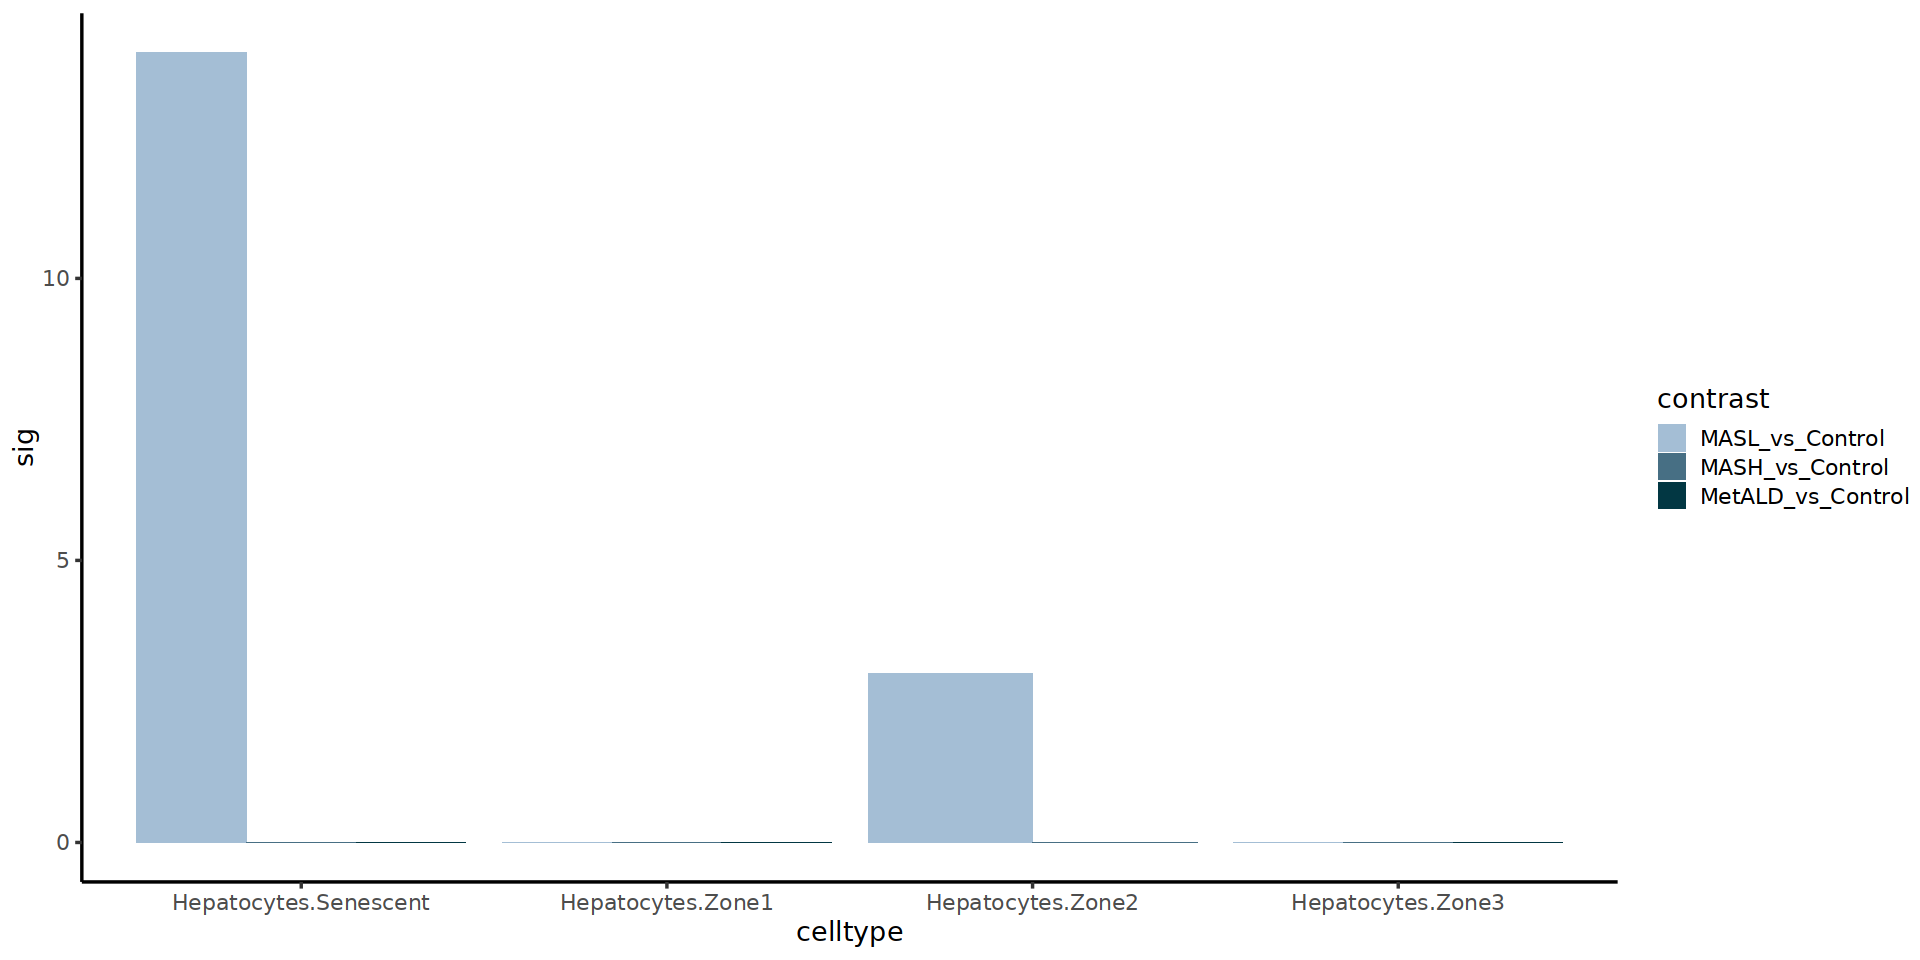

In [92]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [93]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]

        # Run DESeq2
        tryCatch({
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
            
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
            #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

 - MASH_ALL_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

In [94]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [95]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1
Hepatocytes.Zone1,0,0,0,0
Hepatocytes.Zone2,3,0,NA,0
Hepatocytes.Zone3,0,0,0,0


In [96]:
deseq.stats2 <- deseq.stats

In [97]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

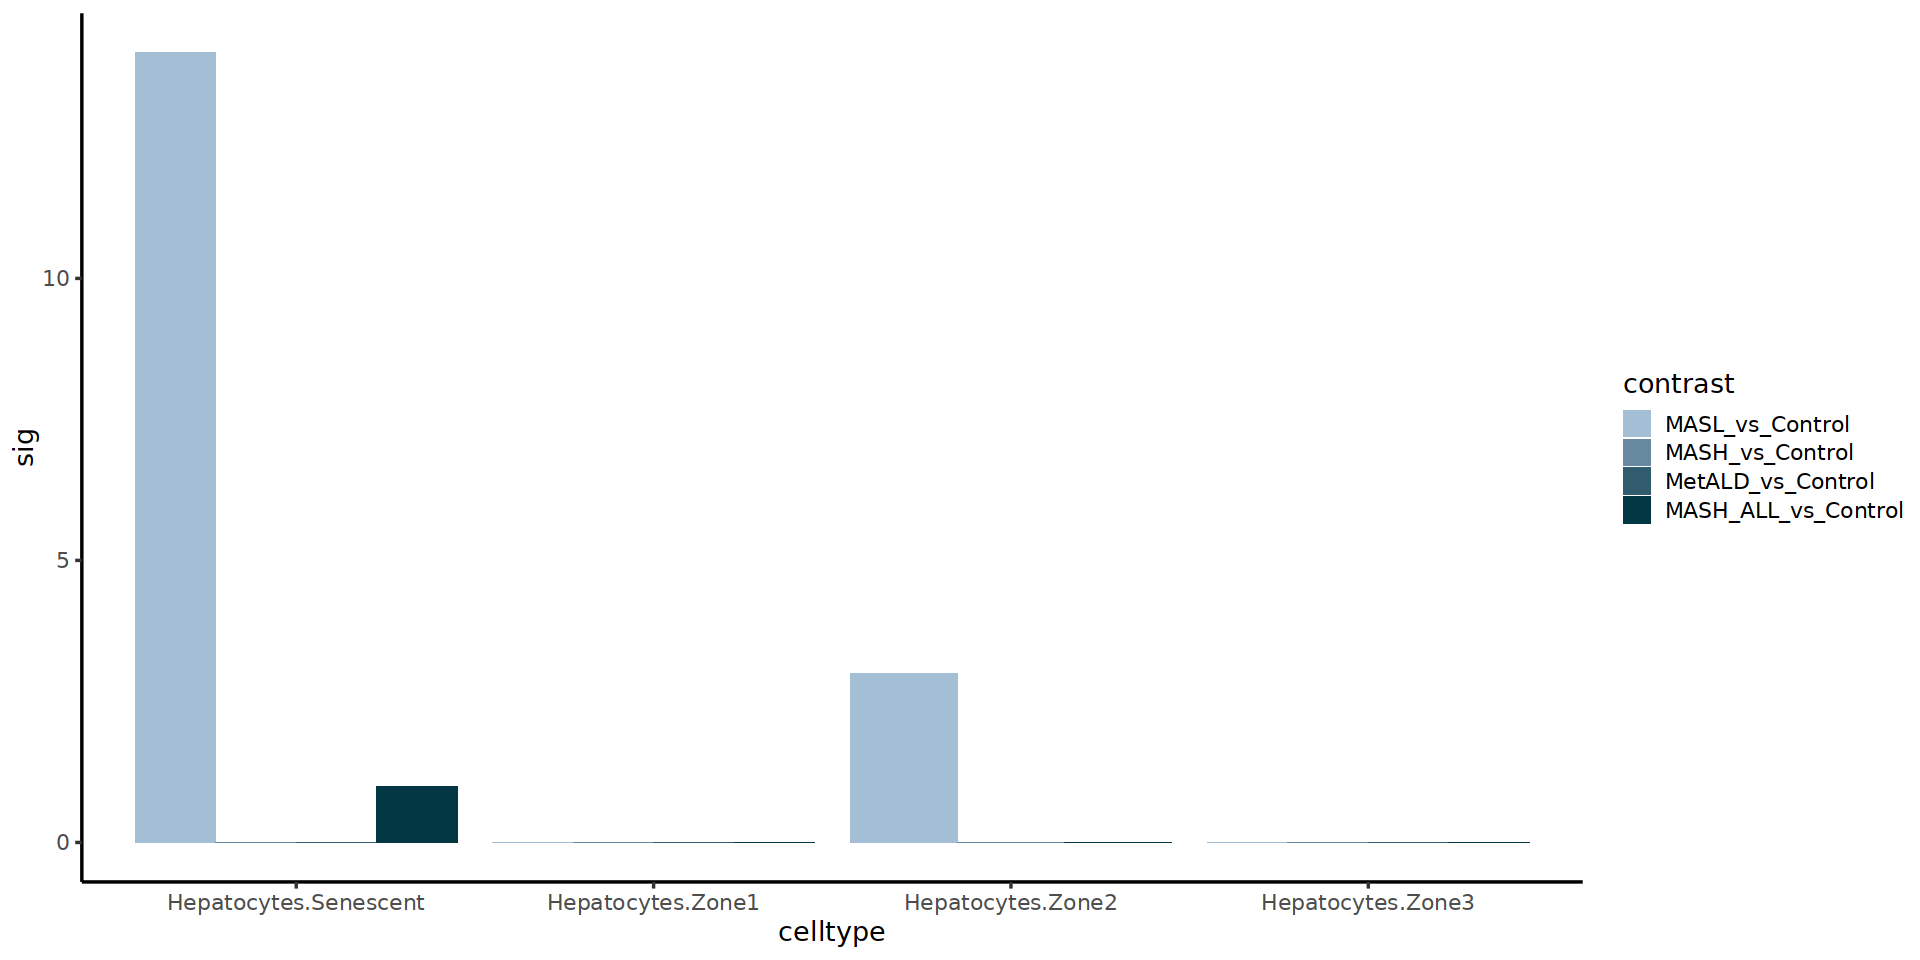

In [98]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [99]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [100]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



In [101]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [102]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0
Hepatocytes.Zone1,0,0,0,0,1
Hepatocytes.Zone2,3,0,NA,0,0
Hepatocytes.Zone3,0,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0


In [103]:
deseq.stats2 <- deseq.stats

In [104]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

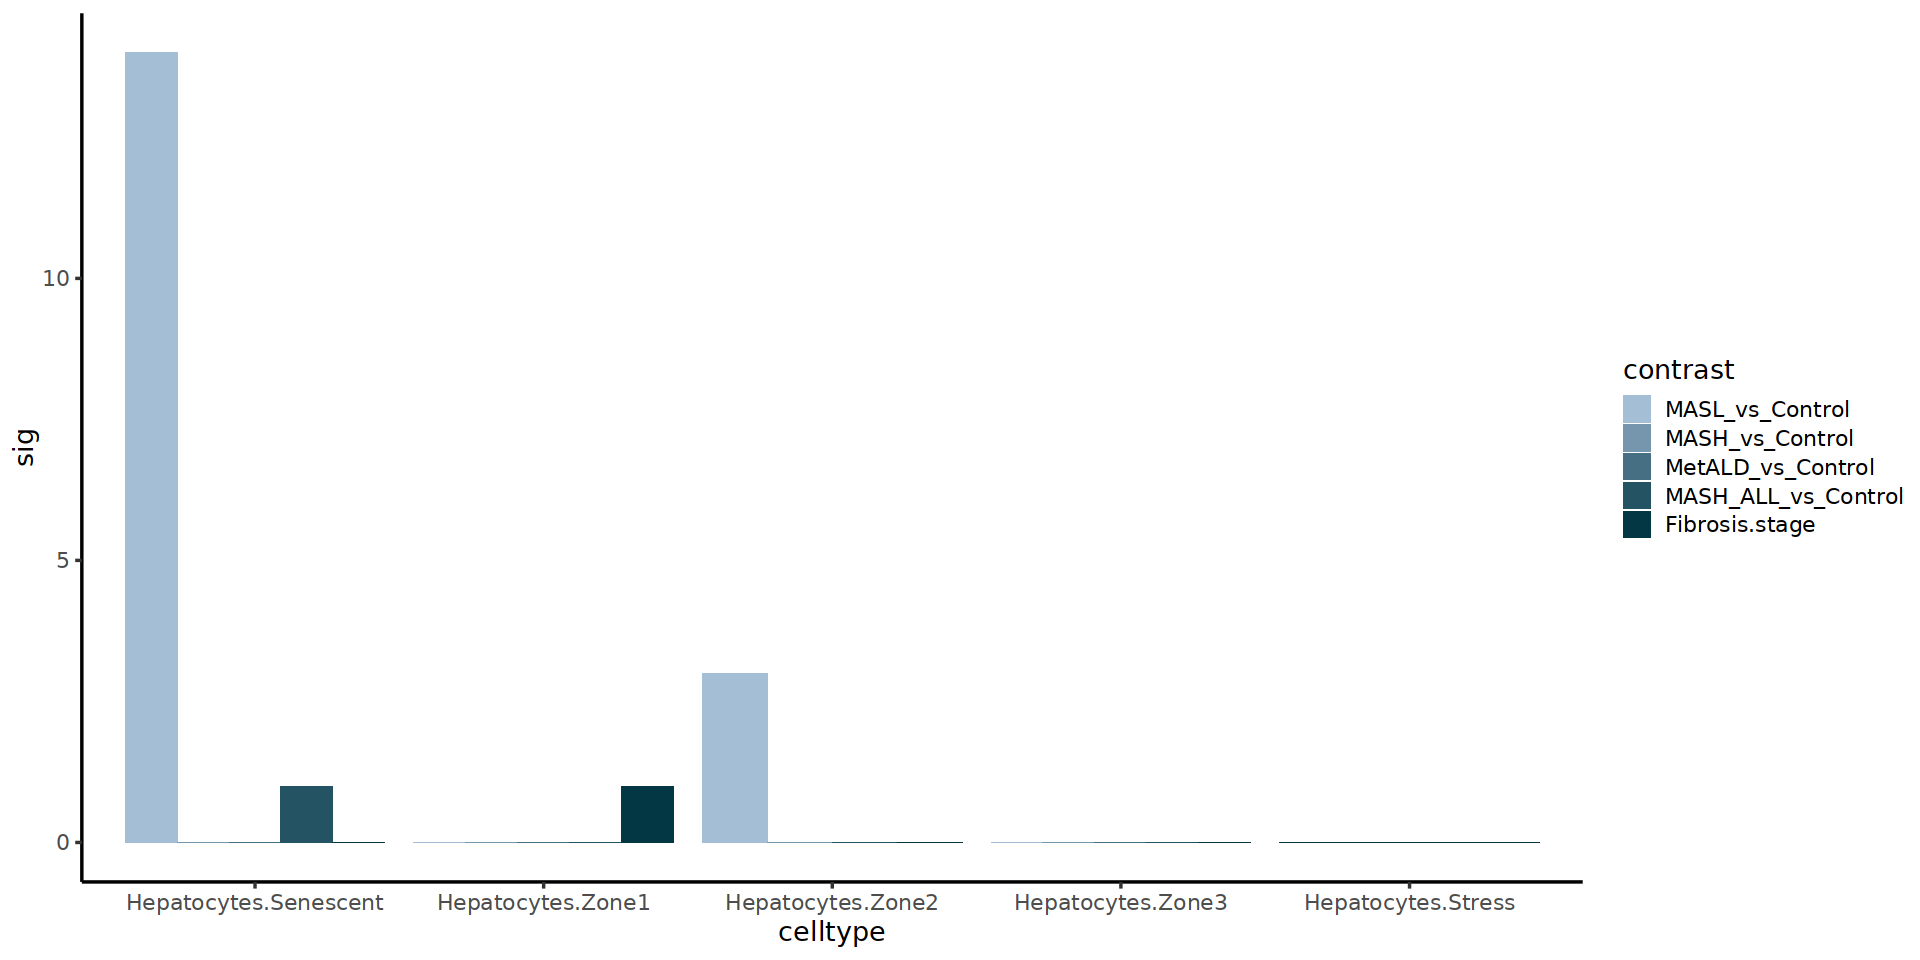

In [105]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [106]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [107]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [108]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [109]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [110]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2


In [111]:
deseq.stats2 <- deseq.stats

In [112]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

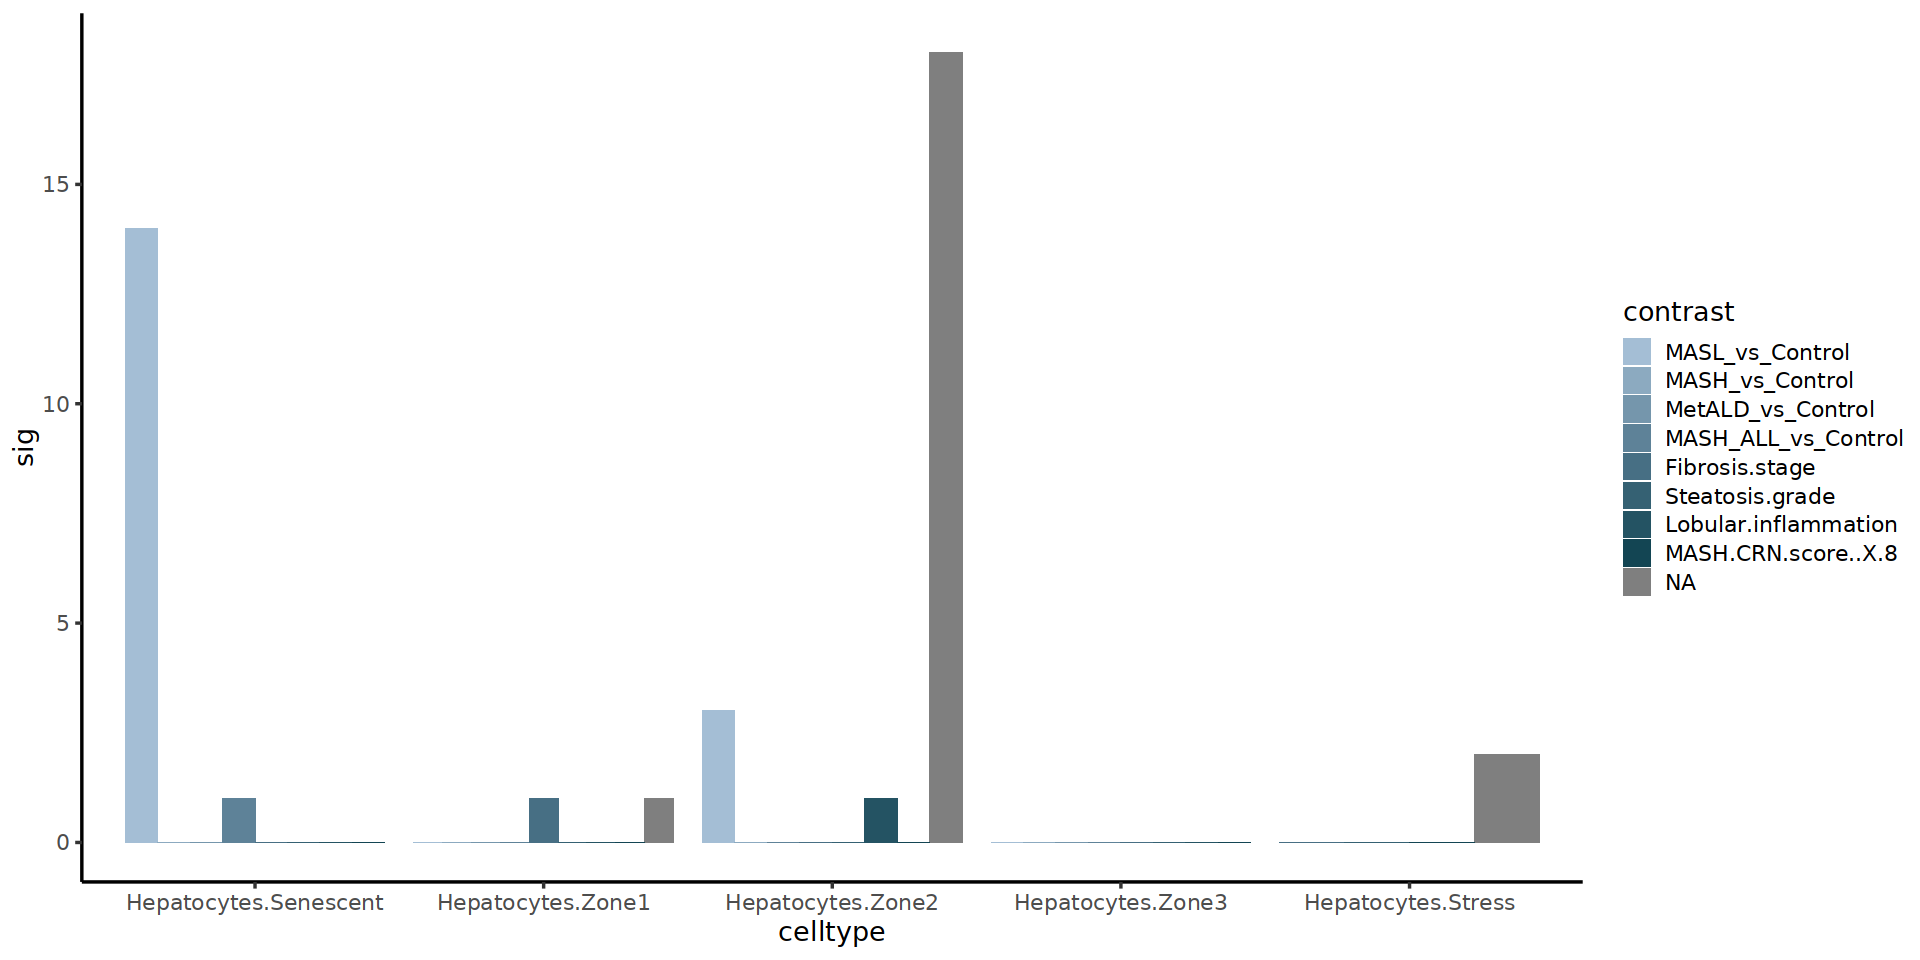

In [113]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

In [114]:
length(unique(deseq.stats2$contrast))

[1] 9

In [115]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [116]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [117]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [118]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0


In [119]:
deseq.stats2 <- deseq.stats

In [120]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

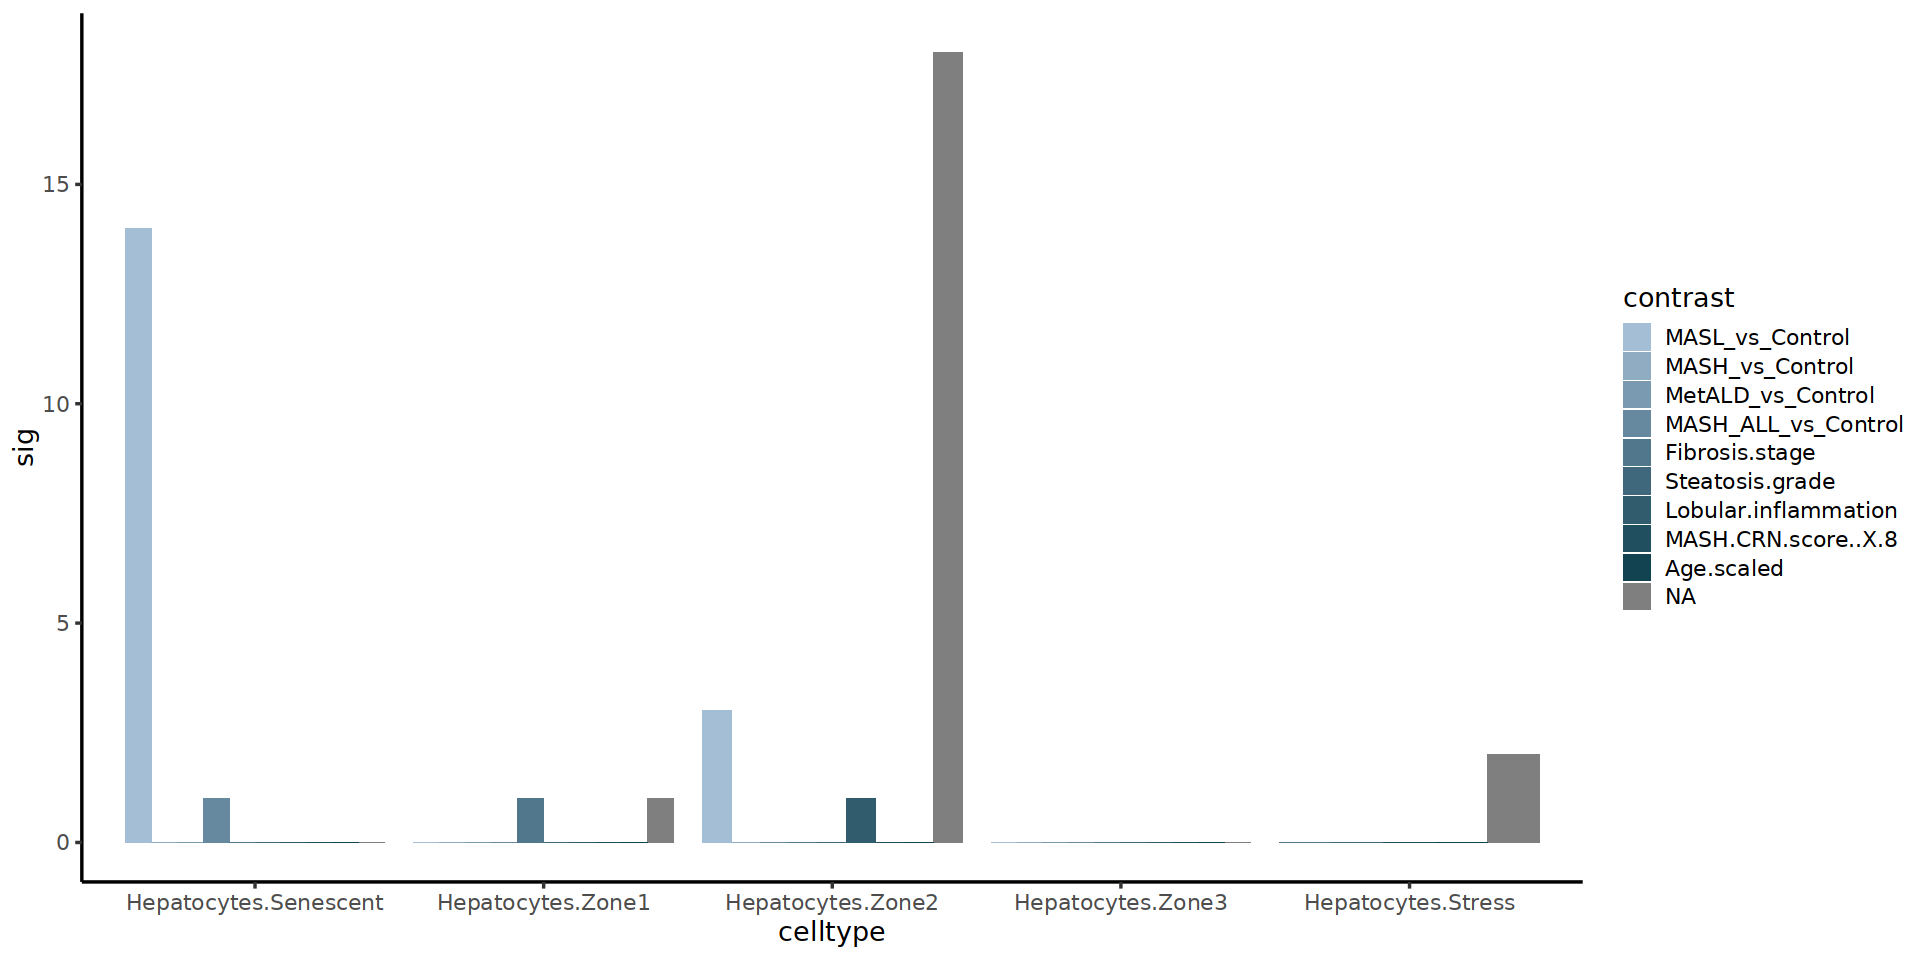

In [121]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [122]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [123]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [124]:
deseq.stats <- distinct(deseq.stats)
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [125]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0


In [126]:
deseq.stats2 <- deseq.stats

In [127]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

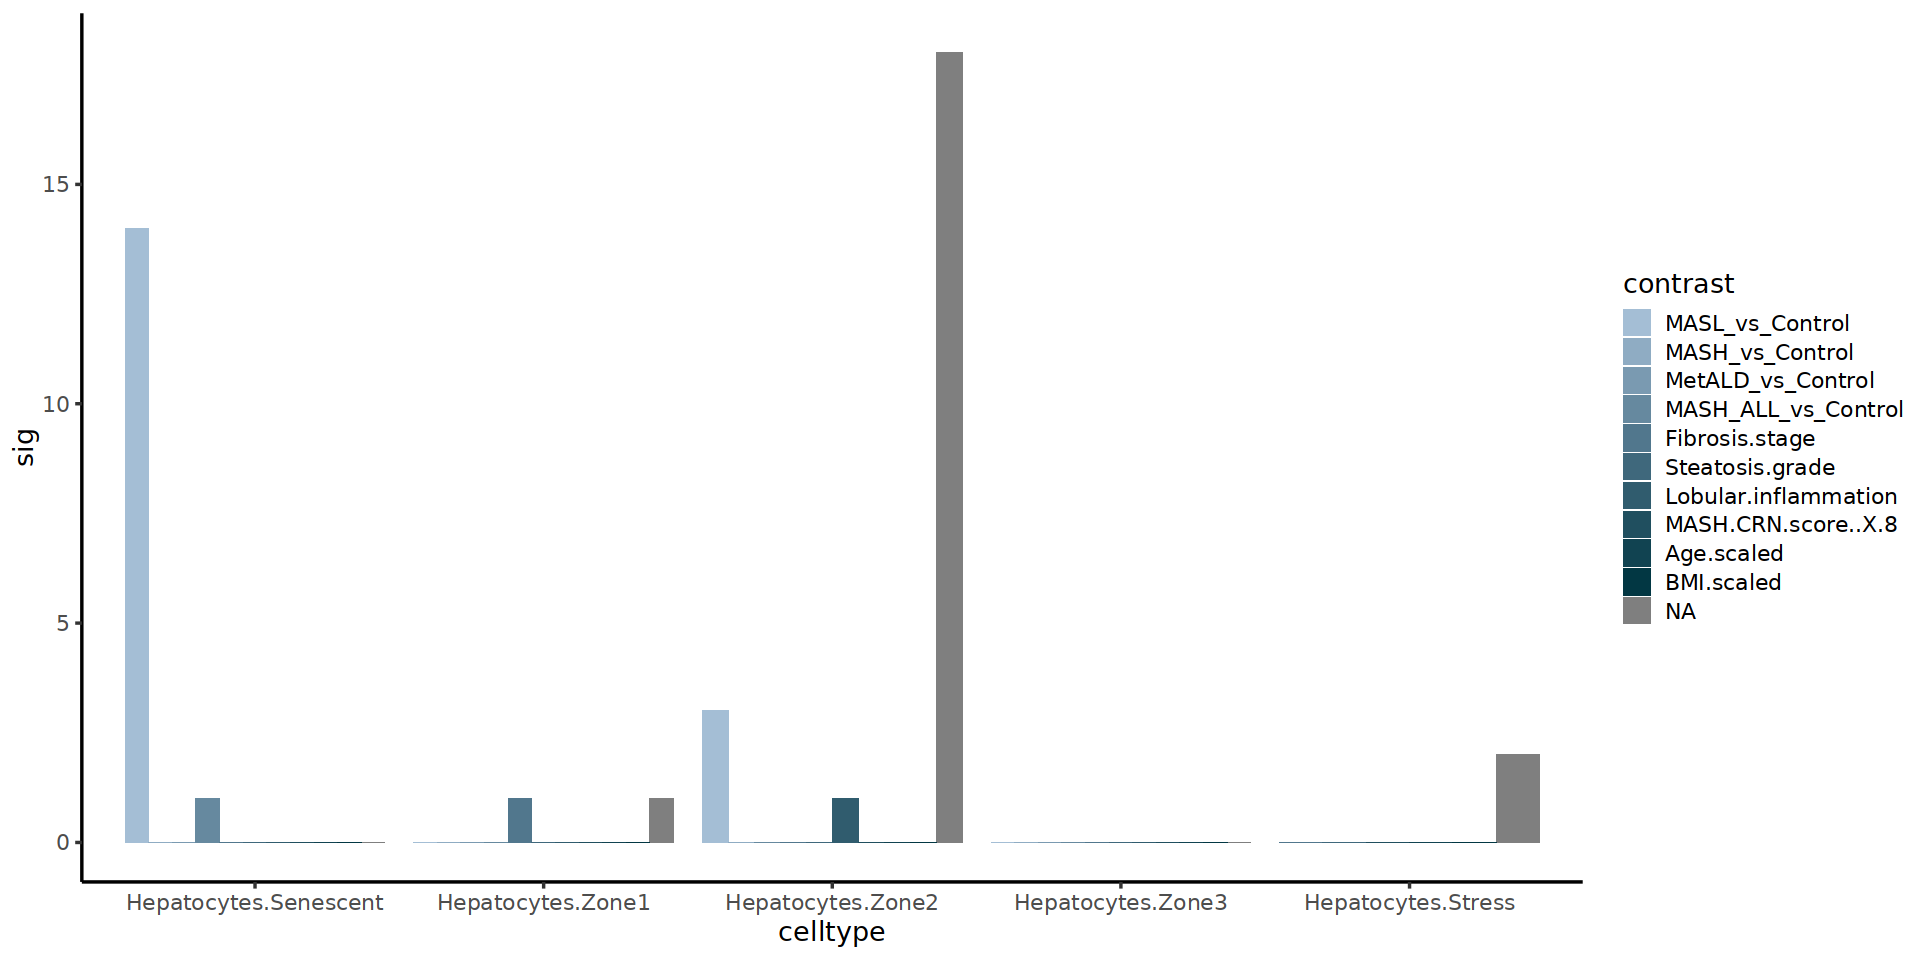

In [128]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [129]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary_add_contrasts_v2.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [130]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [131]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [132]:
seq_along(files)

[1] 1 2 3 4 5

In [133]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

  - Low_Fibrosis_vs_Control

  - High_Fibrosis_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

In [134]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [135]:
outdir

[1] "/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/"

In [136]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0,0,2
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0,0,NA
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0,1,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0,NA,NA


In [137]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0,0,2
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0,0,NA
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0,1,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0,NA,NA


In [143]:
deseq.stats2 <- deseq.stats

In [153]:
unique(deseq.stats$contrast)

[1] "MASL_vs_Control"          "MASH_vs_Control"         
 [3] "MetALD_vs_Control"        "MASH_ALL_vs_Control"     
 [5] "Fibrosis.stage"           "Steatosis.grade"         
 [7] "Lobular.inflammation"     "MASH.CRN.score..X.8"     
 [9] "Ballooning"               "Age"                     
[11] "Age.scaled"               "BMI"                     
[13] "BMI.scaled"               "Low_Fibrosis_vs_Control" 
[15] "High_Fibrosis_vs_Control"

In [154]:
deseq.stats2 <- filter(deseq.stats2, contrast != 'BMI' & contrast != 'Age' & contrast != 'Ballooning' & contrast != 'MASH.CRN.score..X.8')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'Age.scaled', 'BMI.scaled','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

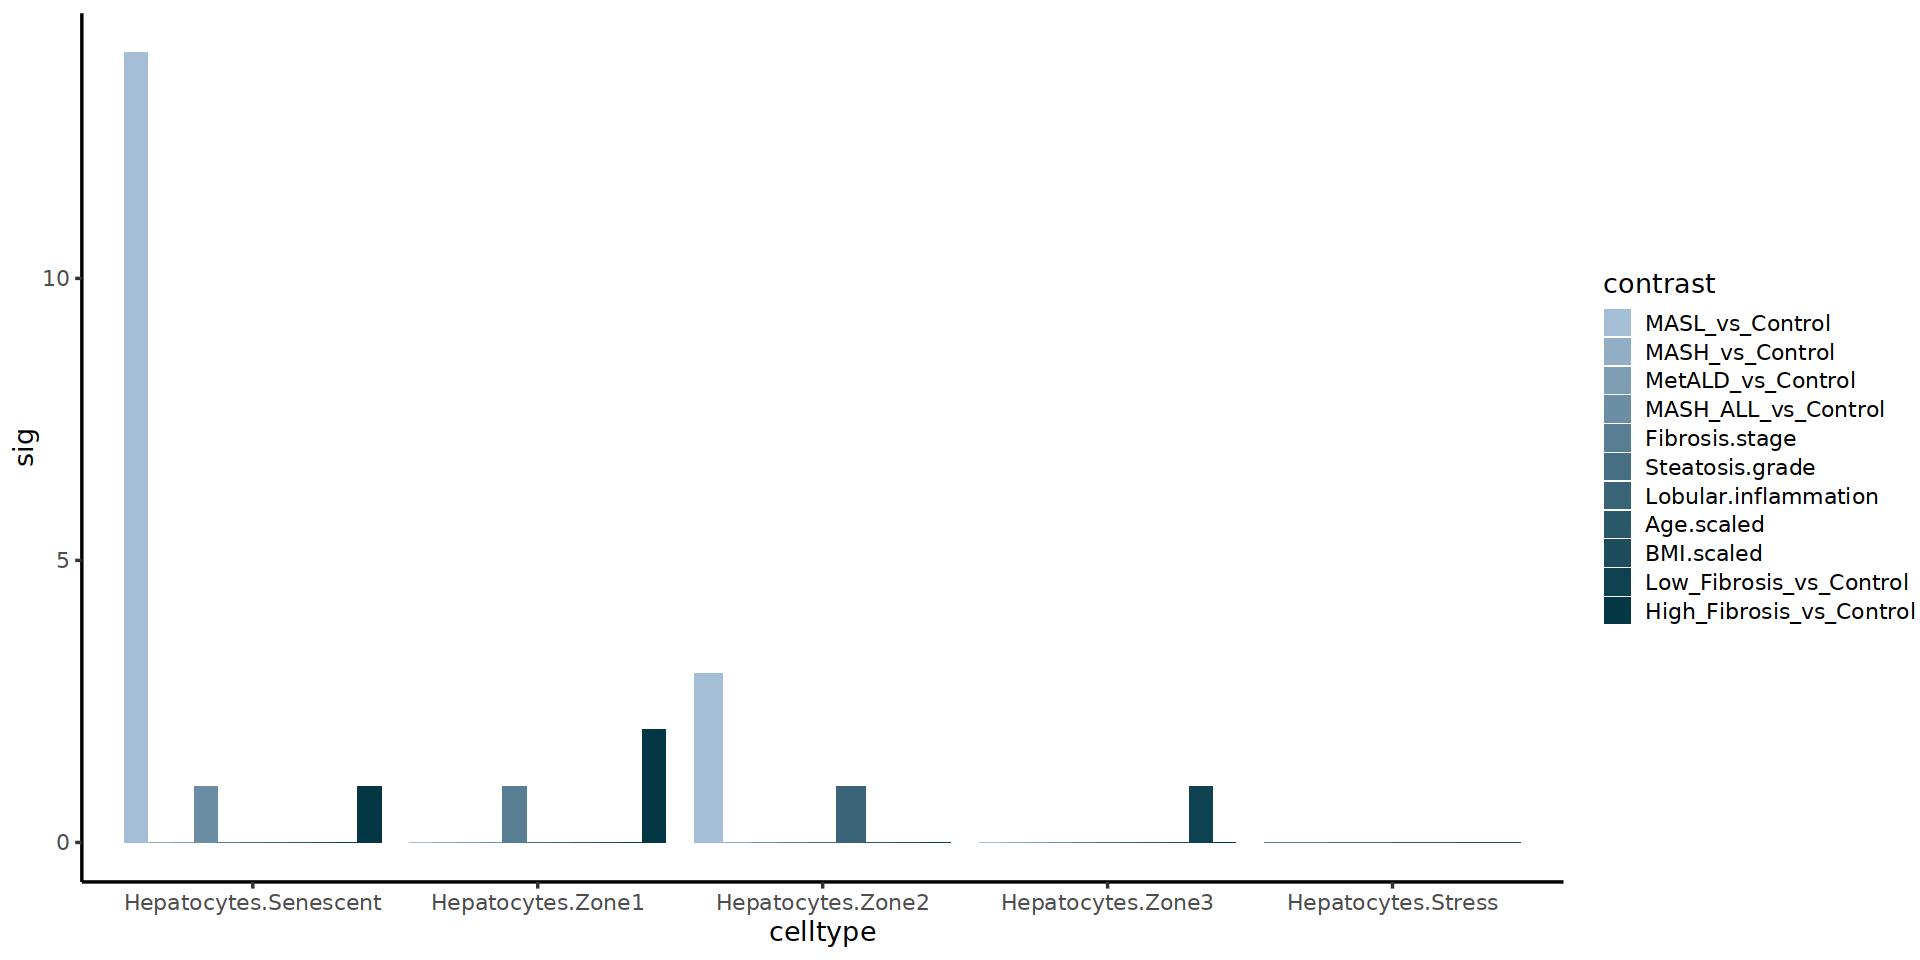

In [155]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

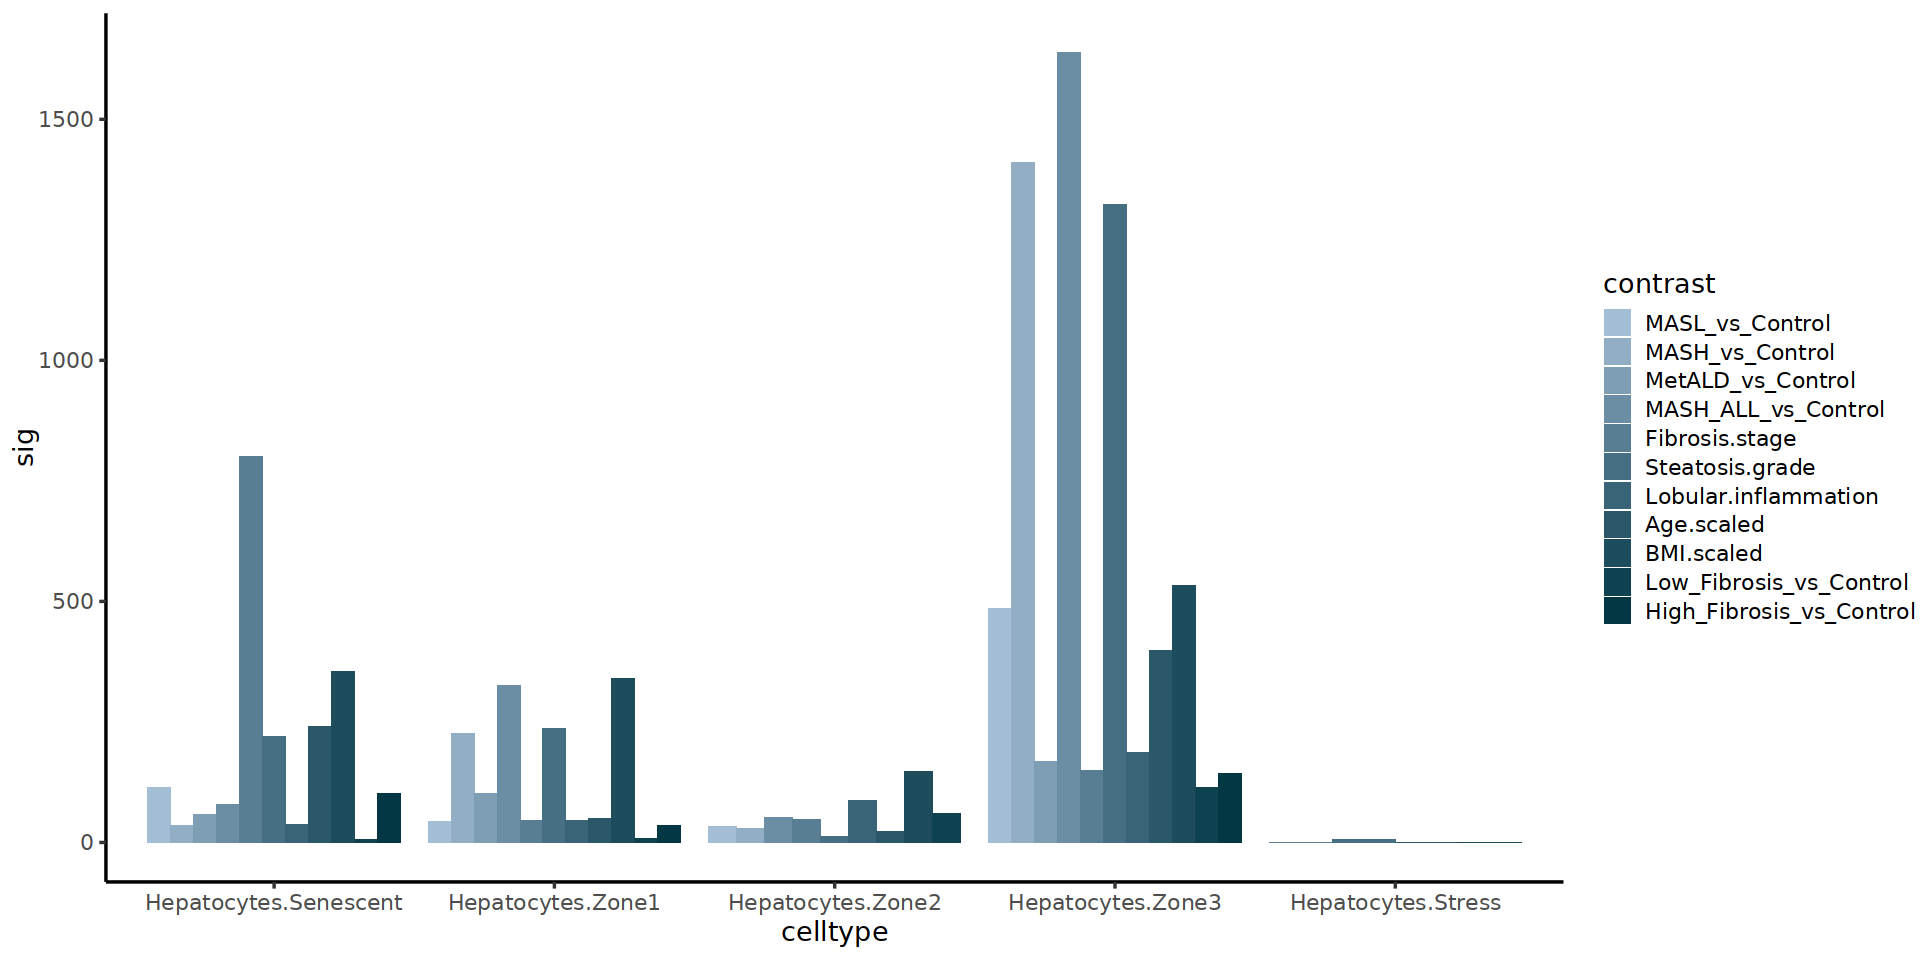

In [156]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_padj, -down_padj) %>%
    pivot_longer(c(up_pval, down_pval), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [159]:
cell.use
file.use

[1] "Hepatocytes.Zone3"

[1] "Hepatocytes.Zone3_counts_spec_subset.tsv"

In [167]:
contrast.use

[1] "High_Fibrosis_vs_Control"

In [168]:
atac.res <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/250131_Hepatocyte_Subtype_DESeq/ATAC/Hepatocytes.Zone3_High_Fibrosis_vs_Control.dds.res', header=T, sep='\t')
atac.res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr11-123590601-123590901,12.368631,3.440666,0.3655128,9.413258,4.809938e-21,1.400188e-15
chr8-138582657-138582957,6.713899,3.793516,0.4378056,8.664842,4.521400e-18,6.580966e-13
chr6-47204315-47204615,4.982749,3.439157,0.4033618,8.526233,1.511905e-17,1.467066e-12
chr4-74632616-74632916,3.405790,3.336520,0.3940919,8.466350,2.532022e-17,1.842698e-12
chr8-138569842-138570142,5.380002,3.776770,0.4515168,8.364628,6.030478e-17,3.510981e-12
chr4-180923510-180923810,2.920123,3.463421,0.4206918,8.232681,1.830698e-16,8.882029e-12
chr14-96192161-96192413,4.538282,3.113206,0.3803127,8.185910,2.702543e-16,1.123883e-11
chr11-130638689-130638989,6.438808,2.894545,0.3584284,8.075658,6.711365e-16,2.442123e-11
chr9-38434897-38435189,7.623051,2.801245,0.3535257,7.923737,2.304768e-15,7.454720e-11


In [172]:
data.frame(dds.results) %>% arrange(pvalue)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:65081188-65081488,1.0818790,5.771984,1.679099,3.437548,0.0005870065,0.9999998
chr4:6947721-6948021,0.4950142,-11.675593,3.533334,-3.304413,0.0009517561,0.9999998
chr17:7307248-7307548,1.0815953,4.799625,1.487041,3.227636,0.0012481788,0.9999998
chr1:16624163-16624362,1.0918525,4.538337,1.467956,3.091604,0.0019907838,0.9999998
chr13:27251427-27251727,1.3976362,4.312049,1.419364,3.038014,0.0023814276,0.9999998
chr16:56329956-56330256,1.0018707,4.952638,1.634718,3.029659,0.0024483032,0.9999998
chr17:50950654-50950954,1.2313743,4.423964,1.475975,2.997317,0.0027236773,0.9999998
chr2:215749340-215749640,1.5370702,4.298793,1.438049,2.989323,0.0027959608,0.9999998
chr4:153520626-153520926,0.6948113,5.719314,1.939749,2.948481,0.0031933953,0.9999998


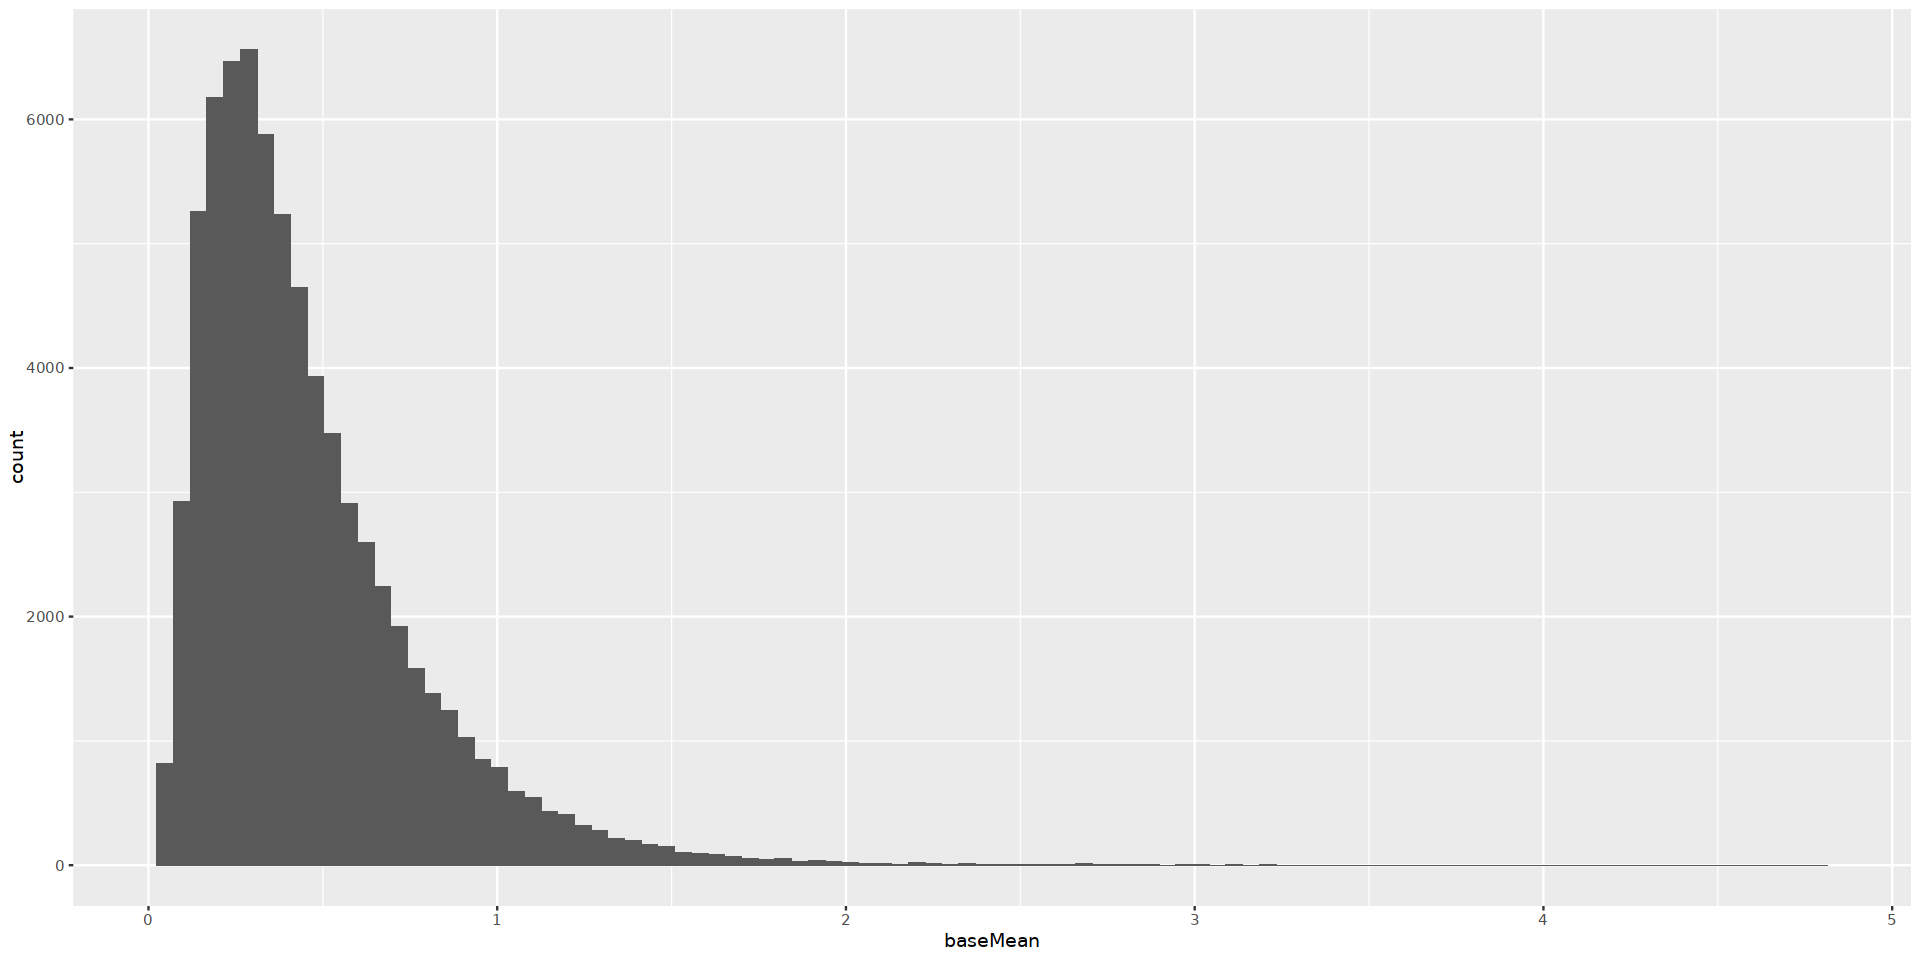

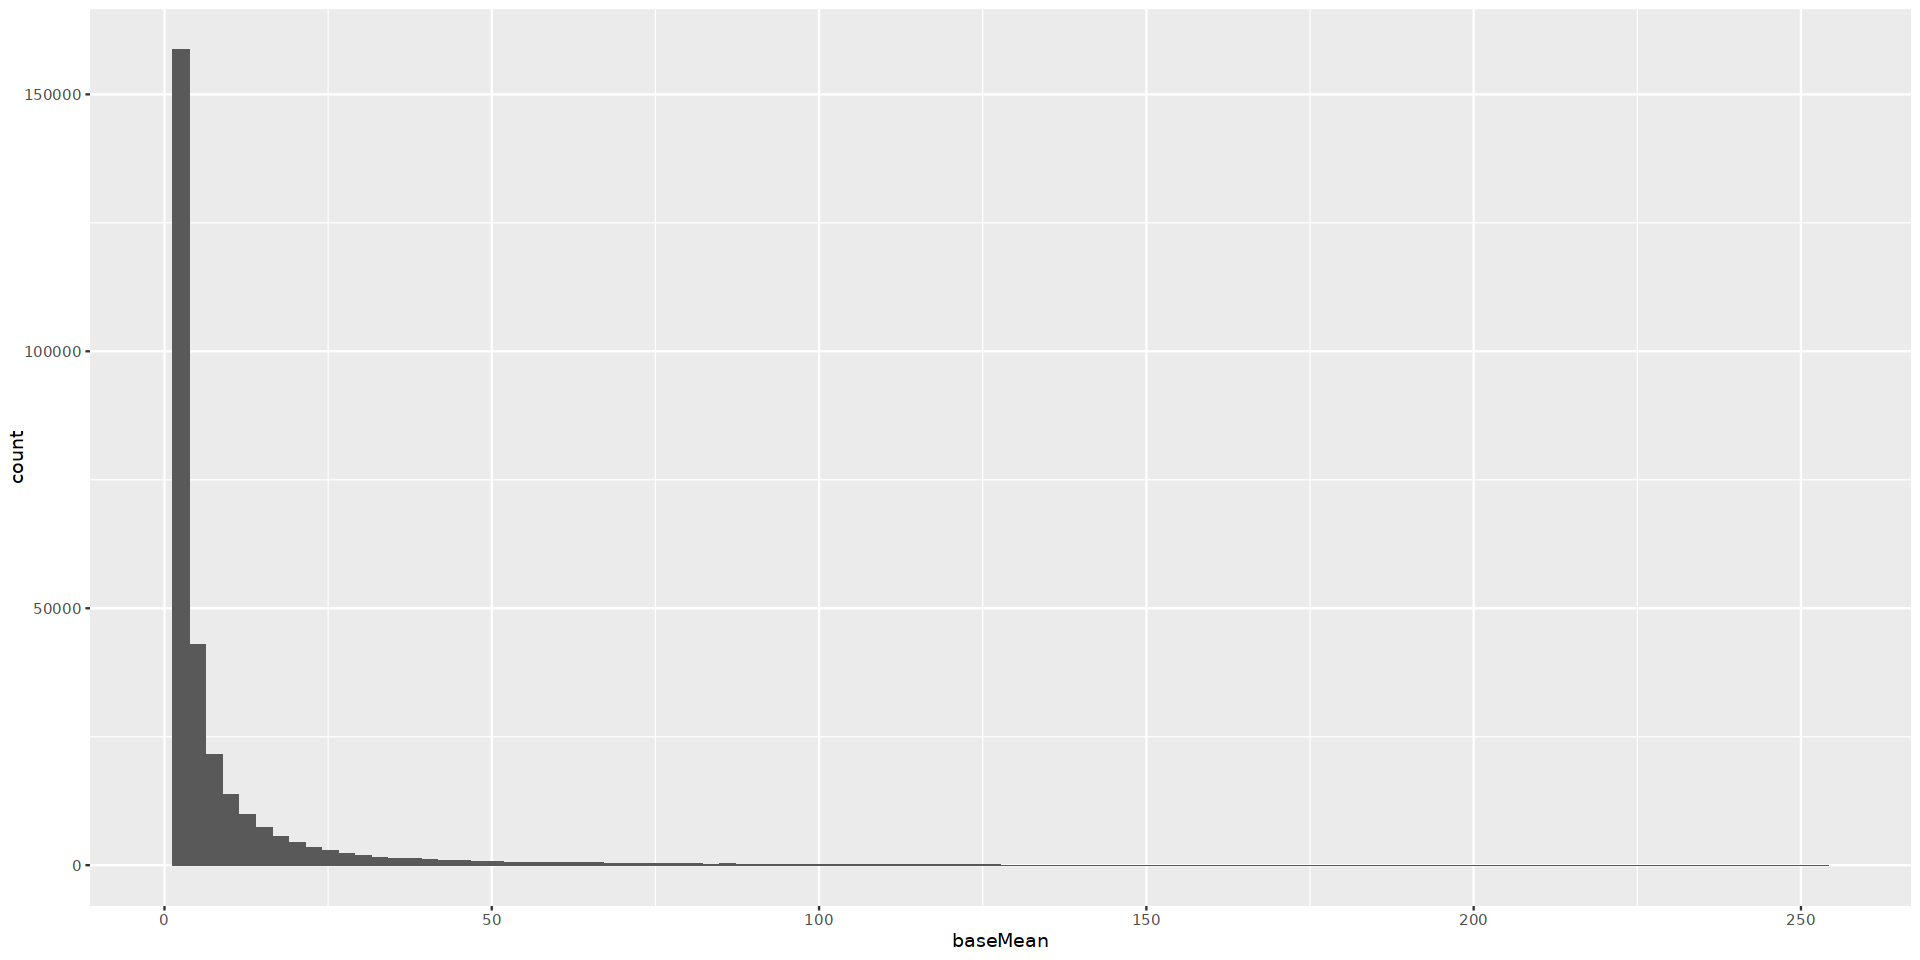

In [179]:
ggplot(data.frame(dds.results), aes(x=baseMean)) + geom_histogram(bins=100)
ggplot(atac.res, aes(x=baseMean)) + geom_histogram(bins=100)

In [175]:
atac.res[str_detect(rownames(atac.res), 'chr2-65081'),]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2-65081674-65081974,9.435878,0.4152449,0.2361270,1.7585660,0.07865126,0.4603033
chr2-65081188-65081488,23.686858,0.1196523,0.1853984,0.6453794,0.51868136,0.8667057


In [ ]:
# Double Check

# Create meta data

In [2]:
adata <- qread('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.qs')
adata

An object of class Seurat 
70217 features across 181892 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap

In [3]:
hep.sub.meta <- select(adata[[]], donor=Donor, Batch, Target, predicted.celltype, predicted.cellsubtype)  %>%
    filter(Target == 'H3K27ac' & predicted.celltype=='Hepatocytes') %>%
    select(-Target, -predicted.celltype) %>% 
    group_by(predicted.cellsubtype, donor) %>%
    summarise(count=n()) %>%
    pivot_wider(names_from = predicted.cellsubtype, values_from = count, values_fill = 0)

hep.sub.meta

`summarise()` has grouped output by 'predicted.cellsubtype'. You can override using the `.groups` argument.


donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,11,2,25,380,116
HL150009,3,4,30,504,220
HL150013,37,3,29,140,72
HL150015,6,8,80,953,219
HL160017,32,1366,4,42,32
HL160022,112,8,6,1,4
HL160026,195,7,123,541,93
HL160029,12,21,678,53,97
HL160030,12,7,36,610,332


In [19]:
hep.sub.meta <- select(adata[[]], donor=Donor, Batch, Target, predicted.celltype, predicted.cellsubtype)  %>%
    filter(Target == 'H3K27ac' & predicted.celltype=='Hepatocytes') %>%
    select(-Target, -predicted.celltype) %>% 
    group_by(predicted.cellsubtype, donor) %>%
    summarise(count=n()) %>%
    pivot_wider(names_from = predicted.cellsubtype, values_from = count, values_fill = 0)

hep.sub.meta

`summarise()` has grouped output by 'predicted.cellsubtype'. You can override using the `.groups` argument.


donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,10,1,34,365,104
HL150009,10,2,33,521,147
HL150013,24,1,32,122,65
HL150015,6,9,82,1070,234
HL160017,25,1668,0,35,30
HL160022,140,7,5,3,3
HL160026,311,8,178,707,138
HL160029,3,24,571,33,87
HL160030,9,0,40,639,394


In [4]:
meta.ct = read.table("/nfs/lab/projects/nash_nafld_liver/downstream_all/08_H3K27ac_DESEQ/H3K27ac.meta.tsv", 
                  sep='\t', header=T)
meta.ct$Age.scaled = scale(meta.ct$Age)
meta.ct$BMI.scaled = scale(meta.ct$BMI)
colnames(meta.ct)
meta.ct$donor <- meta.ct$donor_demux

#meta.ct$HF_status = meta.ct$disease_status
meta.ct

[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "Age.scaled"           "BMI.scaled"

donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,Age.scaled,BMI.scaled,donor
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<chr>
HL150001,12,17,58,534,15,1,78,10,0,⋯,0,0,0,1,M,47,27.10,-0.01553551,-0.638584666,HL150001
HL150009,3,11,104,761,116,0,65,17,3,⋯,0,0,0,1,M,37,29.40,-0.75778750,-0.334686949,HL150009
HL150013,22,37,112,281,77,4,100,20,0,⋯,1,1-2 Mild/moderate,Spotty,3,M,45,35.00,-0.16398591,0.405237926,HL150013
HL150015,12,69,89,1266,66,0,59,15,0,⋯,0,1,0,3,M,59,29.10,0.87516689,-0.374325782,HL150015
HL160017,10,32,71,1476,26,0,234,10,1,⋯,0,2,0,2,M,31,24.00,-1.20313870,-1.048185936,HL160017
HL160022,0,129,45,131,28,0,50,0,2,⋯,1,1,0,5,F,45,29.80,-0.16398591,-0.281835172,HL160022
HL160026,2,18,162,959,105,0,19,7,0,⋯,0,0,Spotty,0,F,25,26.00,-1.64848990,-0.783927052,HL160026
HL160029,19,117,415,861,154,0,191,45,2,⋯,0,0,0,0,F,47,30.86,-0.01553551,-0.141777964,HL160029
HL160030,7,59,228,997,55,0,50,12,3,⋯,0,0,0,2,M,29,30.20,-1.35158910,-0.228983396,HL160030


In [5]:
meta = select(meta.ct, -B, -Cholangiocyte, -Endothelial, -Hepatocytes, -HSC,
      -Mast, -Myeloid, -NK, -Schwann, -T) %>% full_join(hep.sub.meta)
meta

Joining with `by = join_by(donor)`


donor_demux,batch,disease_status,condition,Steatosis.grade,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,⋯,Age,BMI,Age.scaled,BMI.scaled,donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,⋯,<int>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,2262024,Disease,MASL,1,0,Centrizonal,0,0,0,⋯,47,27.10,-0.01553551,-0.638584666,HL150001,11,2,25,380,116
HL150009,2262024,Disease,MASL,1,0,centrizonal,0,0,0,⋯,37,29.40,-0.75778750,-0.334686949,HL150009,3,4,30,504,220
HL150013,10252023,Disease,MASH,1,2,"Centrilobular, Diffuse",1,1,1-2 Mild/moderate,⋯,45,35.00,-0.16398591,0.405237926,HL150013,37,3,29,140,72
HL150015,2262024,Disease,MASL,3,1,"Centrilobular, Diffuse",0,0,1,⋯,59,29.10,0.87516689,-0.374325782,HL150015,6,8,80,953,219
HL160017,2262024,Disease,MetALD,1,2,Centrilobular,1,0,2,⋯,31,24.00,-1.20313870,-1.048185936,HL160017,32,1366,4,42,32
HL160022,10252023,Disease,MASH,3,2,Diffuse,1,1,1,⋯,45,29.80,-0.16398591,-0.281835172,HL160022,112,8,6,1,4
HL160026,2262024,Control,Control,0,0,0,0,0,0,⋯,25,26.00,-1.64848990,-0.783927052,HL160026,195,7,123,541,93
HL160029,8012023,Control,Control,0,0,<5%,0,0,0,⋯,47,30.86,-0.01553551,-0.141777964,HL160029,12,21,678,53,97
HL160030,10252023,Disease,MASL,2,0,N/A,0,0,0,⋯,29,30.20,-1.35158910,-0.228983396,HL160030,12,7,36,610,332


In [6]:
write.table(meta, '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/H3K27ac_Hep_Subtypes.DESeq.meta.data.v2.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')

# Split counts

In [11]:
#always run this first!!
#essential reticulate functions that allow us to use python packages in R
#you'll need a conda env with 'leidenalg' and 'pandas' installed to do this
#then route reticulate to the python installed in that conda env with the below functions
Sys.setenv(RETICULATE_PYTHON="/home/welison/.conda/envs/decontX_reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/welison/.conda/envs/decontX_reticulate/bin/python")
reticulate::use_condaenv("/home/welison/.conda/envs/decontX_reticulate")
reticulate::py_module_available(module='leidenalg') #needs to be TRUE
reticulate::import('leidenalg') #good to make sure this doesn't error
reticulate::import('anndata') #good to make sure this doesn't error

Warning message:
“package ‘reticulate’ was built under R version 4.3.3”


ERROR: Error in reticulate::use_python("/home/welison/.conda/envs/decontX_reticulate/bin/python"): failed to initialize requested version of Python


In [ ]:
library(anndata)

In [9]:
DPT.dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/DPT.files/'
H3K27ac <- read_h5ad(paste0(DPT.dir, 'FNIH_Liver_pool.H3K27ac.LiverUnionPeaks.h5ad'))
H3K27ac

ERROR: No module named 'anndata'

In [7]:
count.full <- vroom::vroom('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/FNIH_Liver_pool.H3K27ac_cellsubtype_fib_donor.LiverUnionPeaks.rpm.csv',
                        delim=',')
colnames(count.full)[1] <- 'peaks'
count.full <- tibble::column_to_rownames(count.full, var='peaks')

dim(count.full)
head(count.full)
gc()

New names:
• `` -> `...1`
Rows: 612056 Columns: 1563
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr    (1): ...1
dbl (1562): HL150001:Activated.HSC:MASL, HL150001:B:MASL, HL150001:Cholangio...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 612056   1562

,HL150001:Activated.HSC:MASL,HL150001:B:MASL,HL150001:Cholangiocyte:MASL,HL150001:Hepatocytes.Senescent:MASL,HL150001:Hepatocytes.Zone1:MASL,HL150001:Hepatocytes.Zone2:MASL,HL150001:Hepatocytes.Zone3:MASL,HL150001:Kupffer:MASL,HL150001:Macrophage:MASL,HL150001:Mast:MASL,⋯,HL230325:Lipid.Associated.Macrophage:MASH_low,HL230325:Macrophage:MASH_low,HL230325:Mesenchymal:MASH_low,HL230325:NK:MASH_low,HL230325:Plasma:MASH_low,HL230325:Quescent.HSC:MASH_low,HL230325:Schwann:MASH_low,HL230325:Sinusoidal.Endothelial:MASH_low,HL230325:T:MASH_low,HL230325:Vascular.Endothelial:MASH_low
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9967-10267,0,0,0,0,1,6,4,4,1,0,⋯,1,0,0,3,1,0,0,1,0,0
chr1:16085-16372,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:17357-17657,0,0,0,0,0,0,0,2,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:29216-29497,0,0,0,0,0,0,1,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:102789-103089,0,0,0,0,0,1,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1:136647-136947,0,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9442742,504.3,13825014,738.4,13825014,738.4
Vcells,3638668427,27760.9,5211572010,39761.2,3644472456,27805.2


In [60]:
for (sub in c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Stress','Hepatocytes.Senescent')) {
    sub.mat <- select(count.full, contains(sub))
    colnames(sub.mat) <- str_split(colnames(sub.mat), ':', simplify=T)[,1]
    
    print(ncol(sub.mat))
    print(nrow(sub.mat))
    
    write.table(sub.mat, paste0('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/', sub, '_counts.tsv'),
           sep='\t', col.names=T, row.names=T, quote=F)
}

[1] 56
[1] 612056
[1] 51
[1] 612056
[1] 81
[1] 612056
[1] 28
[1] 612056
[1] 68
[1] 612056


In [65]:
Hep.peaks <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/Hepatocytes_union.peaks',
          header=F, sep='\t') %>%
            mutate(peak=paste0(V1,':',V2,'-',V3)) %>%
            select(peak) %>%
            unlist()

length(Hep.peaks)
head(Hep.peaks)

[1] 329833

peak1                peak2                peak3 
   "chr1:9967-10267"   "chr1:16085-16372"   "chr1:17357-17657" 
               peak4                peak5                peak6 
  "chr1:29216-29497" "chr1:102789-103089" "chr1:136647-136947"

In [66]:
sum(Hep.peaks %in% rownames(sub.mat))

[1] 329833

In [68]:
for (sub in c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Stress','Hepatocytes.Senescent')) {
    sub.mat <- select(count.full, contains(sub))
    colnames(sub.mat) <- str_split(colnames(sub.mat), ':', simplify=T)[,1]
    
    sub.mat <- sub.mat[Hep.peaks,]
    
    print(ncol(sub.mat))
    print(nrow(sub.mat))
    
    write.table(sub.mat, paste0('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/', sub, '_counts_spec_subset.tsv'),
           sep='\t', col.names=T, row.names=T, quote=F)
}

[1] 56
[1] 329833
[1] 51
[1] 329833
[1] 81
[1] 329833
[1] 28
[1] 329833
[1] 68
[1] 329833


# Differential Testing

In [83]:
meta = read.table("/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/H3K27ac_Hep_Subtypes.DESeq.meta.data.v2.tsv", 
                  sep='\t', header=T)
head(meta, n = 2)
#meta$Age.scaled = scale(meta$Age)
colnames(meta)
meta$donor <- meta$donor_demux

#meta$HF_status = meta$disease_status

,donor_demux,batch,disease_status,condition,Steatosis.grade,Fibrosis.stage,Fat.distribution,Lobular.inflammation,Ballooning,Portal.inflammation,⋯,Age,BMI,Age.scaled,BMI.scaled,donor,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<int>
1,HL150001,2262024,Disease,MASL,1,0,Centrizonal,0,0,0,⋯,47,27.1,-0.01553551,-0.6385847,HL150001,10,1,34,365,104
2,HL150009,2262024,Disease,MASL,1,0,centrizonal,0,0,0,⋯,37,29.4,-0.75778750,-0.3346869,HL150009,10,2,33,521,147


[1] "donor_demux"           "batch"                 "disease_status"       
 [4] "condition"             "Steatosis.grade"       "Fibrosis.stage"       
 [7] "Fat.distribution"      "Lobular.inflammation"  "Ballooning"           
[10] "Portal.inflammation"   "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"  
[13] "Gender"                "Age"                   "BMI"                  
[16] "Age.scaled"            "BMI.scaled"            "donor"                
[19] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[22] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [72]:
#Pseudobulk matrices directory
dir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/'
#Create outdir for results
outdir <- '/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/'
dir.create(outdir)
#Get list of pseudobulk files
files <- list.files(dir, pattern='_counts_spec_subset.tsv')
#Cut off file suffices to get celltype names
cells <- gsub('_counts_spec_subset.tsv','', files)

files
cells

Warning message in dir.create(outdir):
“'/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes' already exists”


[1] "Hepatocytes.Senescent_counts_spec_subset.tsv"
[2] "Hepatocytes.Stress_counts_spec_subset.tsv"   
[3] "Hepatocytes.Zone1_counts_spec_subset.tsv"    
[4] "Hepatocytes.Zone2_counts_spec_subset.tsv"    
[5] "Hepatocytes.Zone3_counts_spec_subset.tsv"

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [73]:
# List your contrasts  
conditions.1 = c("MASL", "MASH", "MetALD") # disease
conditions.2 = c("Control", "Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [80]:
colnames(meta_cell.use)

[1] "donor_demux"           "disease_status"        "condition"            
 [4] "Steatosis.grade"       "Fibrosis.stage"        "Fat.distribution"     
 [7] "Lobular.inflammation"  "Ballooning"            "Portal.inflammation"  
[10] "Hepatocyte.necrosis"   "MASH.CRN.score..X.8"   "Gender"               
[13] "Age"                   "BMI"                   "Age.scaled"           
[16] "BMI.scaled"            "donor"                 "Hepatocytes.Senescent"
[19] "Hepatocytes.Stress"    "Hepatocytes.Zone1"     "Hepatocytes.Zone2"    
[22] "Hepatocytes.Zone3"

In [74]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [75]:
seq_along(files)

[1] 1 2 3 4 5

In [84]:
deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.1) %>% 
                               pull(donor)
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

  - MASL_vs_Control

  - MASH_vs_Control

  - MetALD_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

  - MASL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [86]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [87]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control
<chr>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0
Hepatocytes.Zone1,0,0,0
Hepatocytes.Zone2,3,0,NA
Hepatocytes.Zone3,0,0,0


In [88]:
deseq.stats2 <- deseq.stats

In [91]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))                           

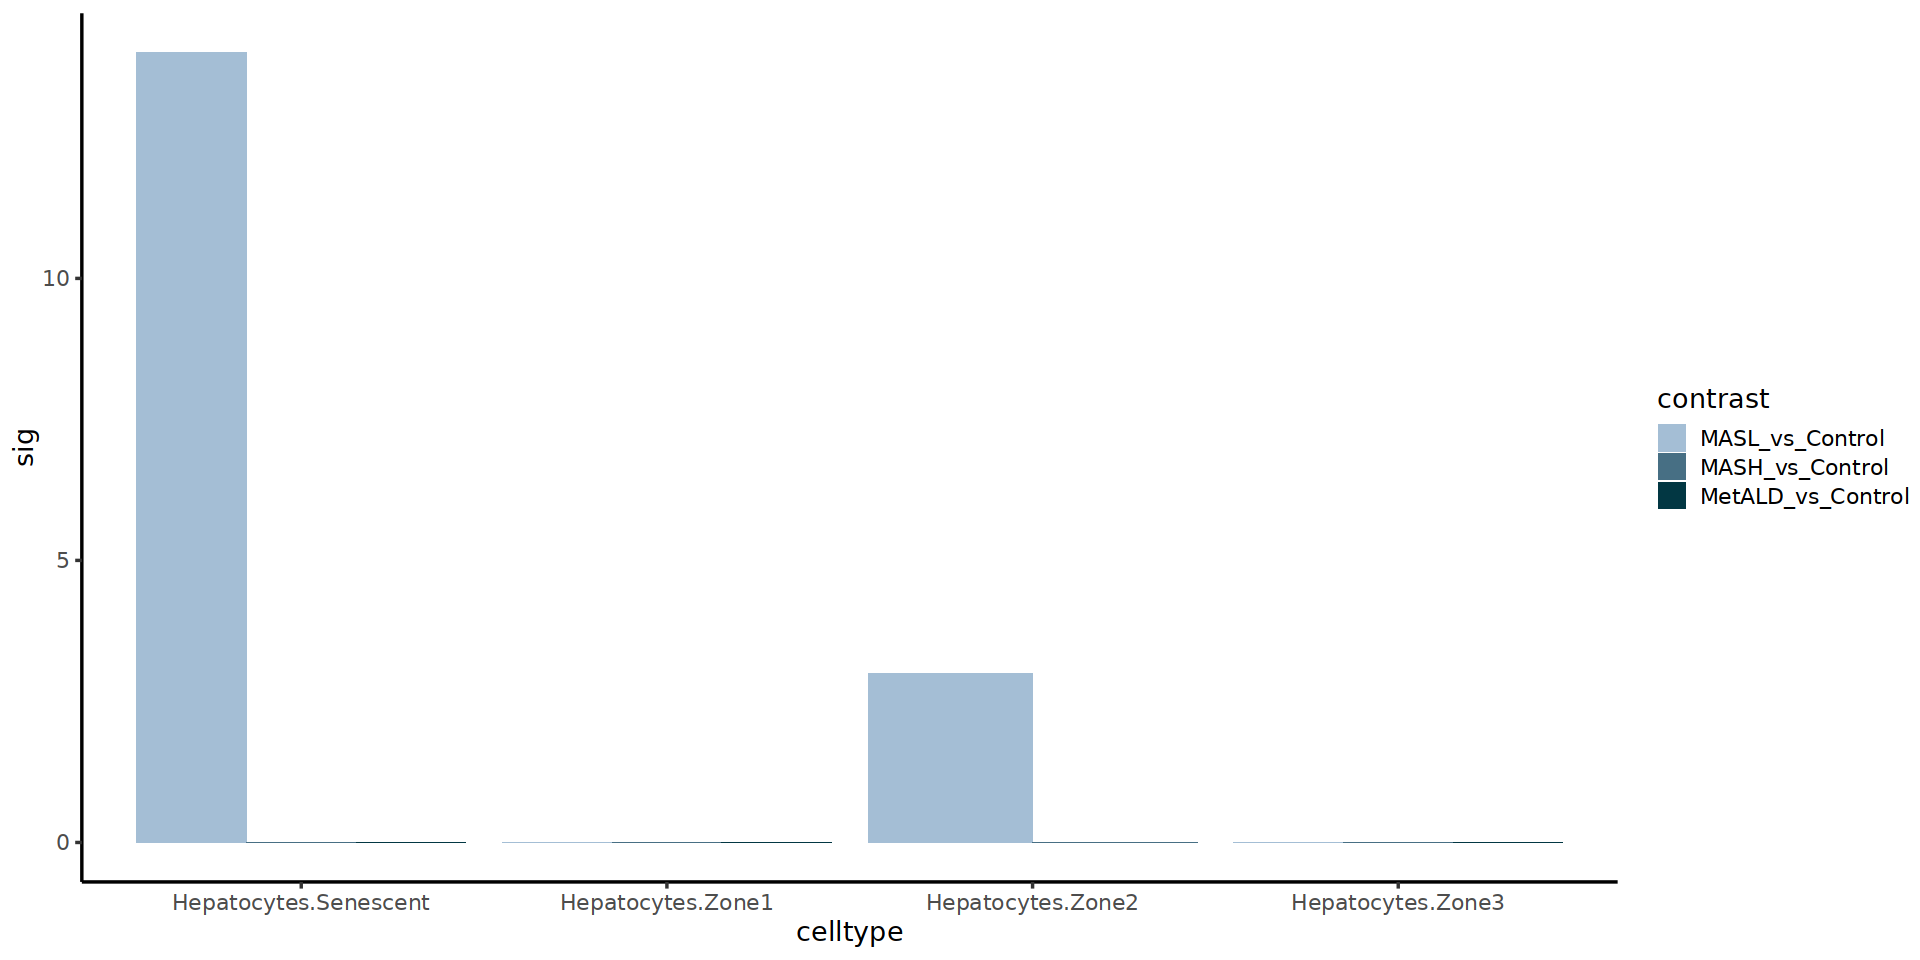

In [92]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### MASH_ALL

In [93]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    contrast.use <- 'MASH_ALL_vs_Control'
    
    condition.1 = c('MASH','MetALD')
    condition.2 = 'Control'
    message(" - ", contrast.use)

    # Create vectors of samples for each condition
    samples.condition.1 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.1) %>% 
                           pull(donor)
    samples.condition.2 <- meta_cell %>% 
                           dplyr::filter(condition %in% condition.2) %>% 
                           pull(donor)
    
    if(length(samples.condition.1) < 3) {
        next
    }
    if(length(samples.condition.2) < 3) {
        next
    }
    
    # Subset meta_cell for the current contrast
    meta_cell.use <- meta_cell %>% 
                 dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
    meta_cell.use[meta_cell.use$condition == 'MASH',]$condition <- 'MASH_ALL'
    meta_cell.use[meta_cell.use$condition == 'MetALD',]$condition <- 'MASH_ALL'
    rownames(meta_cell.use) <- meta_cell.use$donor
    
    # Subset raw_counts for the donors in meta_cell
    raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
    
    # Check if enough samples are present for both conditions
    if (length(unique(meta_cell$condition)) >= 2) {
        deseq.stats.tmp <- data.frame()
        
        # Light pre-filtering
        counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]
        counts_filtered <- counts_filtered[,colSums(counts_filtered) > 0]

        # Run DESeq2
        tryCatch({
        dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                      colData = meta_cell.use, 
                                      design = deseq.formula)
        dds$condition <- relevel(dds$condition, ref = condition.2)
        dds <- DESeq(dds)
        dds.results <- results(dds)
            
        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
            
        dds.results <- na.omit(dds.results[order(dds.results$padj), ])

        # Write DESeq results to file
        write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
        
        # Collect summary statistics
        deseq.stats.tmp <- data.frame(
            celltype = cell.use,
            contrast = contrast.use,
            up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
            down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
            up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
            down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
            deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                       # Make Volcano plot - Padj
                        res = as.data.frame(dds.results)
                        res$SYMBOL = rownames(res)
                        res = res %>%
                        dplyr::filter(!is.na(SYMBOL)) %>%
                        dplyr::filter(padj < 0.1) %>%
                        dplyr::group_by(sign(log2FoldChange)) %>%
                        dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                        dplyr::top_n(50, rank) %>%
                        dplyr::mutate(delabel = SYMBOL) %>%
                        ungroup() %>%
                        dplyr::select(delabel, SYMBOL) %>%
                        right_join(res) %>%
                        dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                        # Add a new column for color based on significance and direction
                        res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                            ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                        # Get the number of upregulated and downregulated genes
                        n_up <- sum(res$changes == "Up-regulated")
                        n_down <- sum(res$changes == "Down-regulated")

                        # Modify log2FoldChange values to be max x
                        res$log2FoldChange[res$log2FoldChange > 10] <- 10
                        res$log2FoldChange[res$log2FoldChange < -10] <- -10
                        # Modify padj values to be max x 
                        res$padj[res$padj < 10^-200] <- 10^-200
                
                        plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                            theme_bw() +
                            labs(y="-log10(padj)", x="log2FoldChange", 
                               title=paste(cell.use, " - ",
                                           condition.1, "Vs", condition.2, "\n",
                                          "Up: ", n_up, "-",
                                           "Down: ", n_down)) +
                            geom_point() +
                            scale_color_manual(values=c("blue", "grey", "red")) + 
                            theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                            scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                        labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                            scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                        labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                            geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                          point.padding=0, min.segment.length=0,
                                          max.time=20, max.iter=1e5, box.padding=0.3)
                
                        ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                               height = 10, width = 10,
                               plot = plot, device = "pdf")
            #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
    } else {
        message("Not enough samples for contrast: ", contrast.use)
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

 - MASH_ALL_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

 - MASH_ALL_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimat

In [94]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [95]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control
<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1
Hepatocytes.Zone1,0,0,0,0
Hepatocytes.Zone2,3,0,NA,0
Hepatocytes.Zone3,0,0,0,0


In [96]:
deseq.stats2 <- deseq.stats

In [97]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control"))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

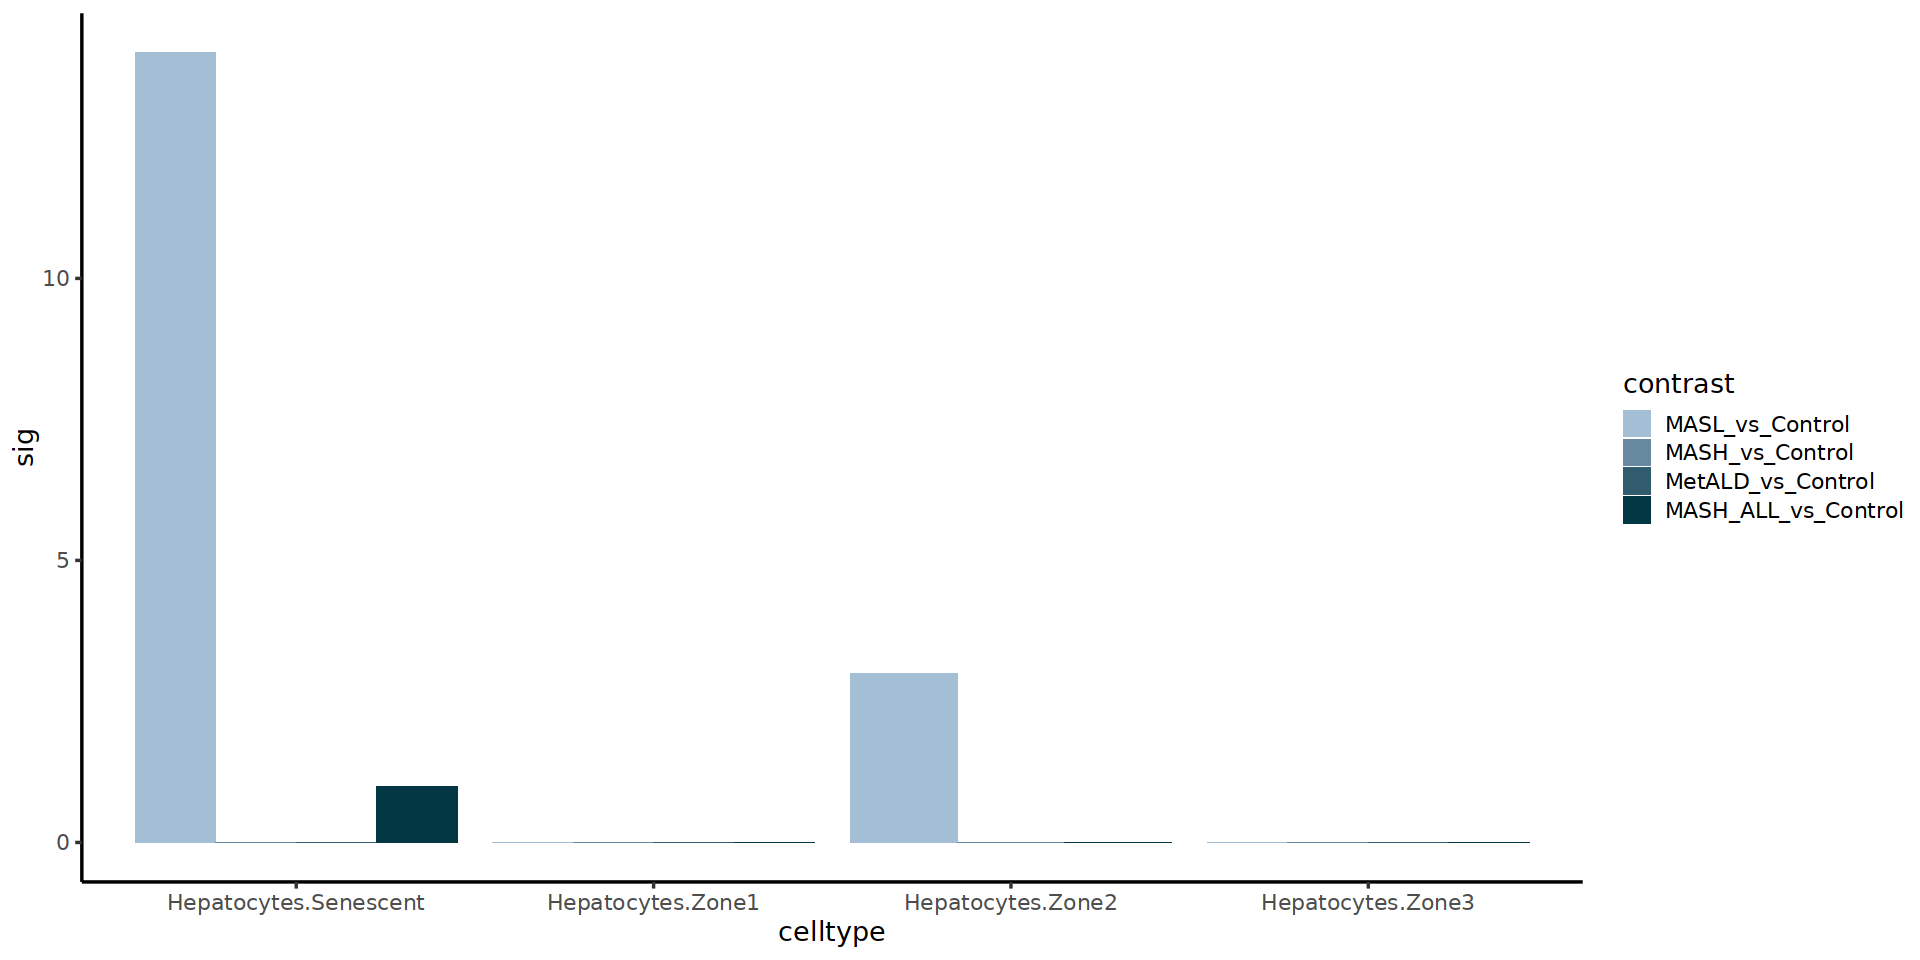

In [98]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

### Fibrosis

In [99]:
contrasts  <- c('Fibrosis.stage')


# Define the DESeq2 formula
deseq.base.formula <- '~ Age.scaled + BMI.scaled + batch + Gender'

In [100]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Fibrosis.stage

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates



In [101]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [102]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0
Hepatocytes.Zone1,0,0,0,0,1
Hepatocytes.Zone2,3,0,NA,0,0
Hepatocytes.Zone3,0,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0


In [103]:
deseq.stats2 <- deseq.stats

In [104]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

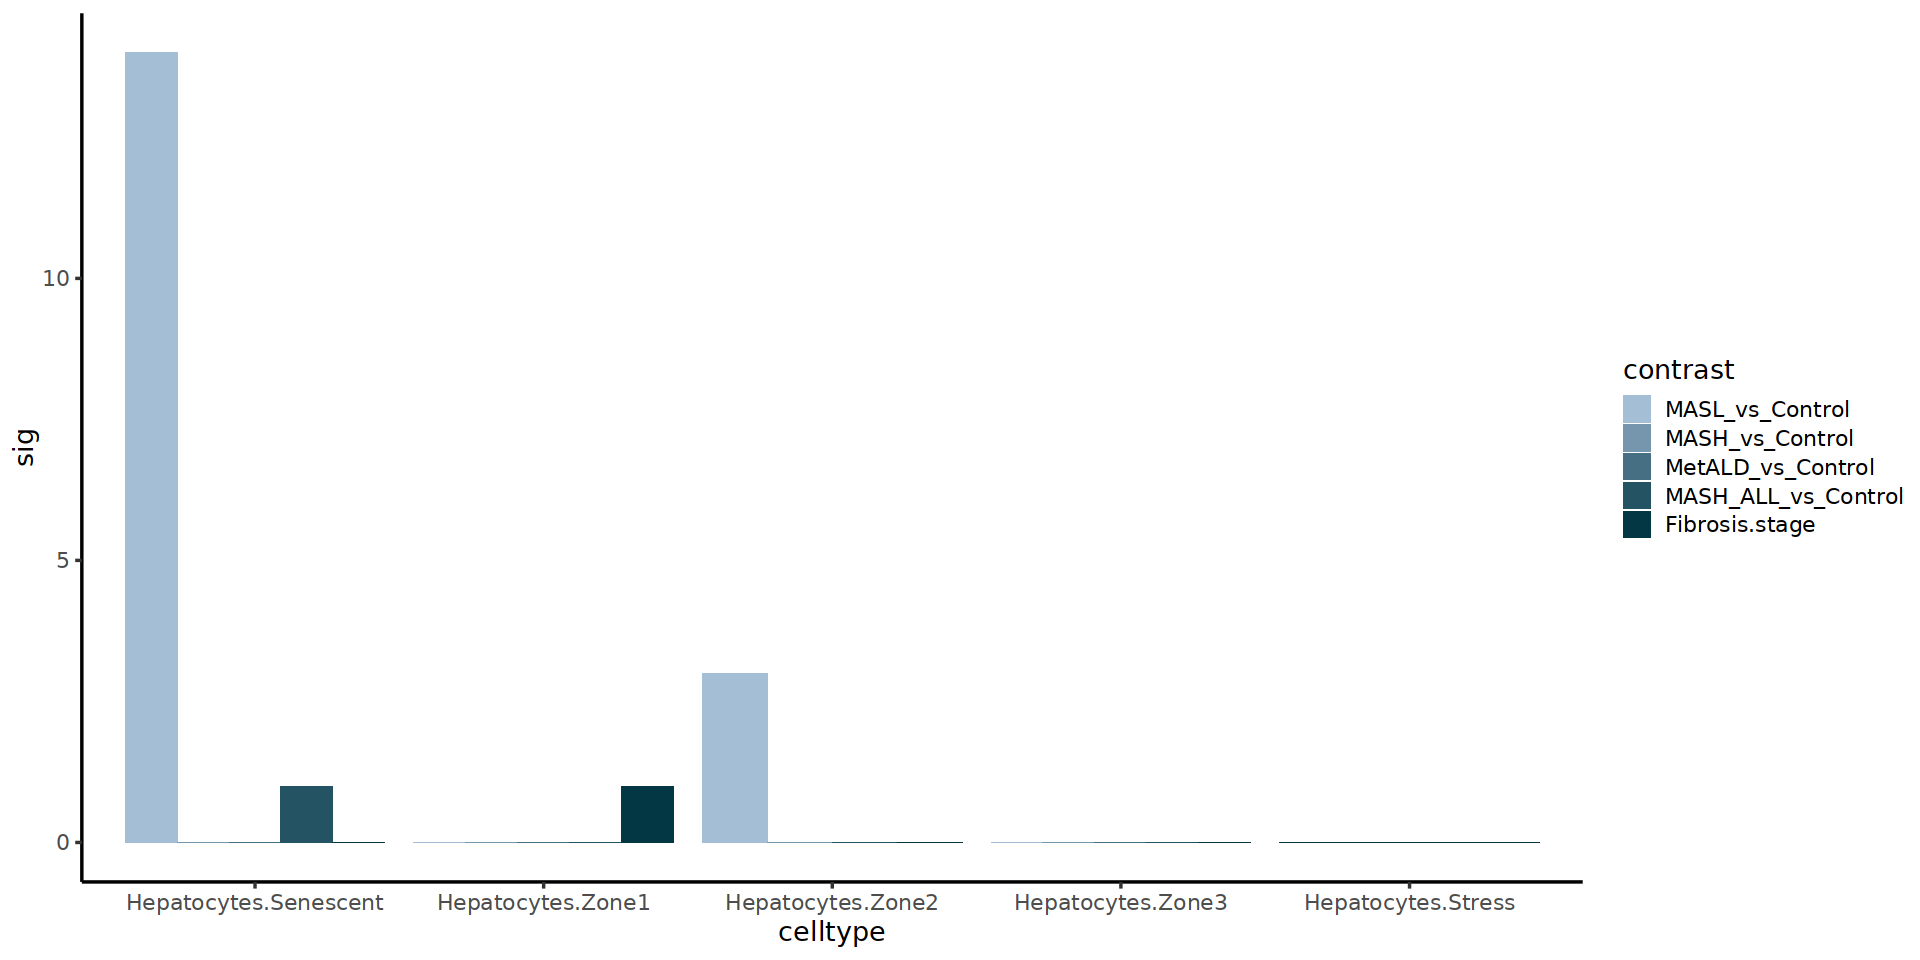

In [105]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [106]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

### Other Meta

In [107]:
contrasts  <- c('Steatosis.grade', 'Lobular.inflammation', 'Ballooning', 'MASH.CRN.score..X.8')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + BMI.scaled + batch + Gender'

In [108]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Steatosis.grade

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates


In [109]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [110]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2


In [111]:
deseq.stats2 <- deseq.stats

In [112]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

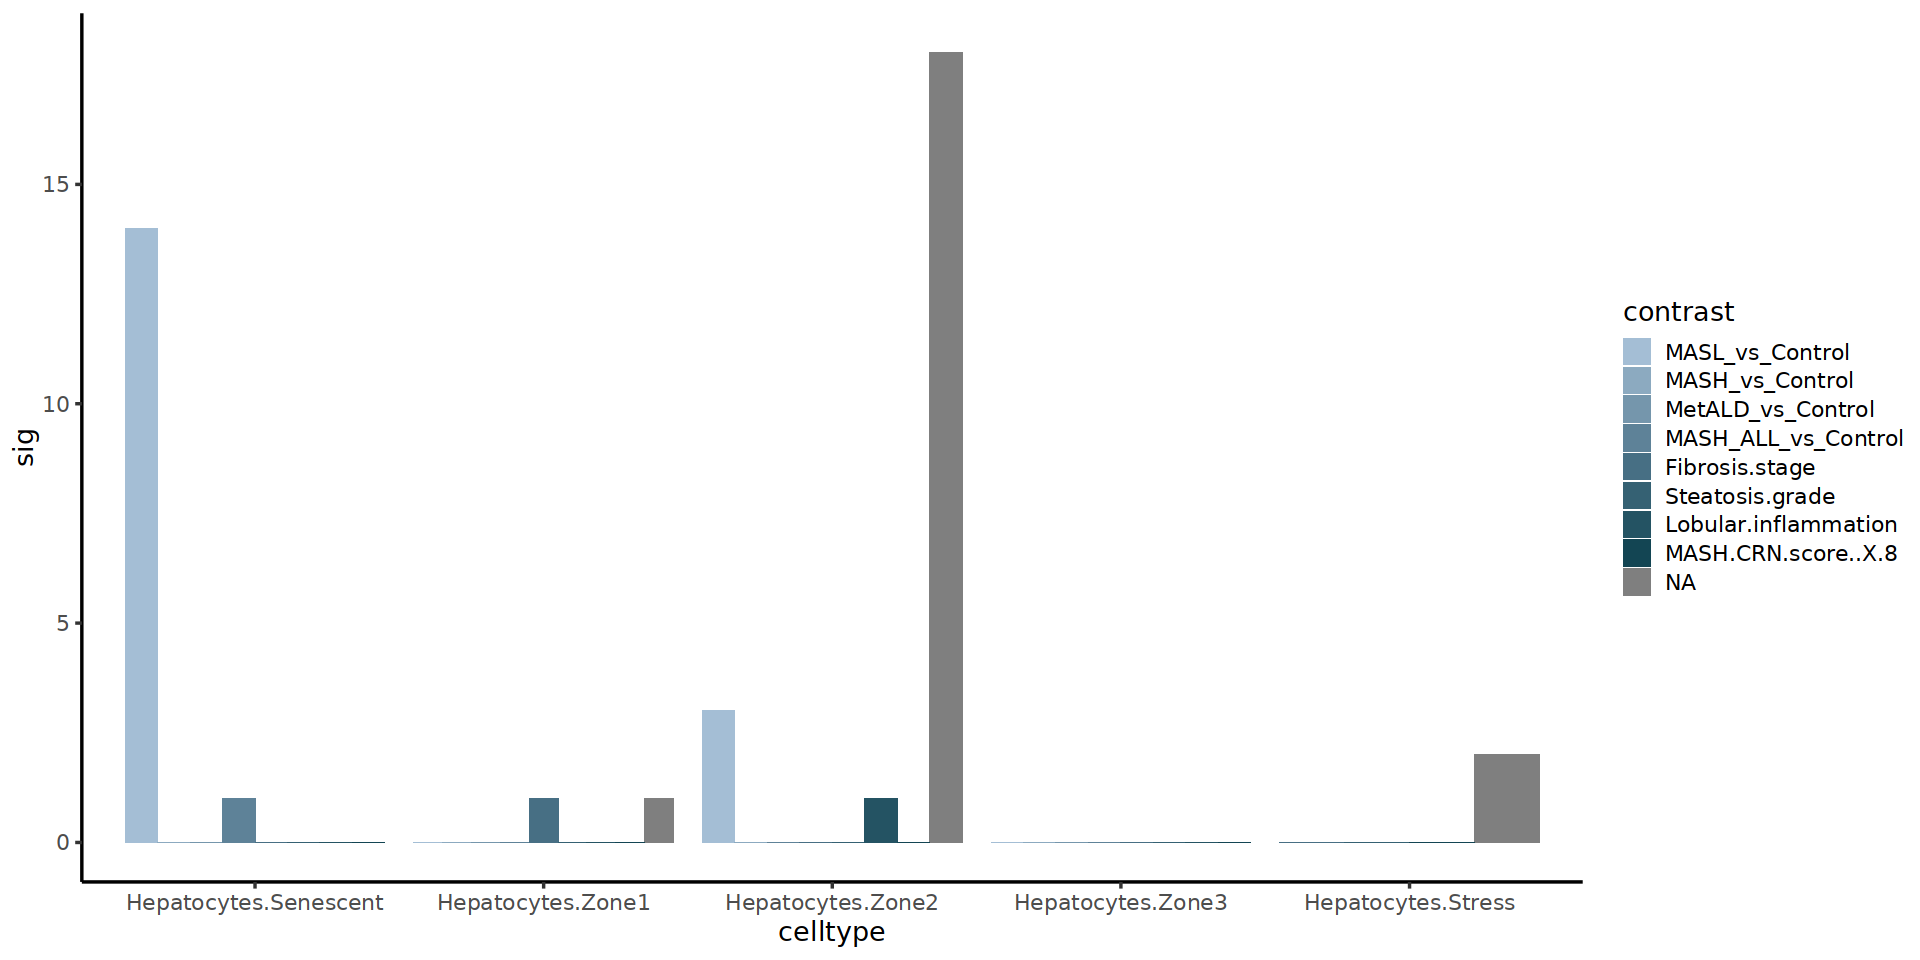

In [113]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(unique(deseq.stats2$contrast))))

In [114]:
length(unique(deseq.stats2$contrast))

[1] 9

In [115]:
contrasts  <- c('Age','Age.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + BMI.scaled + batch + Gender'

In [116]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - Age

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [117]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [118]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0


In [119]:
deseq.stats2 <- deseq.stats

In [120]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

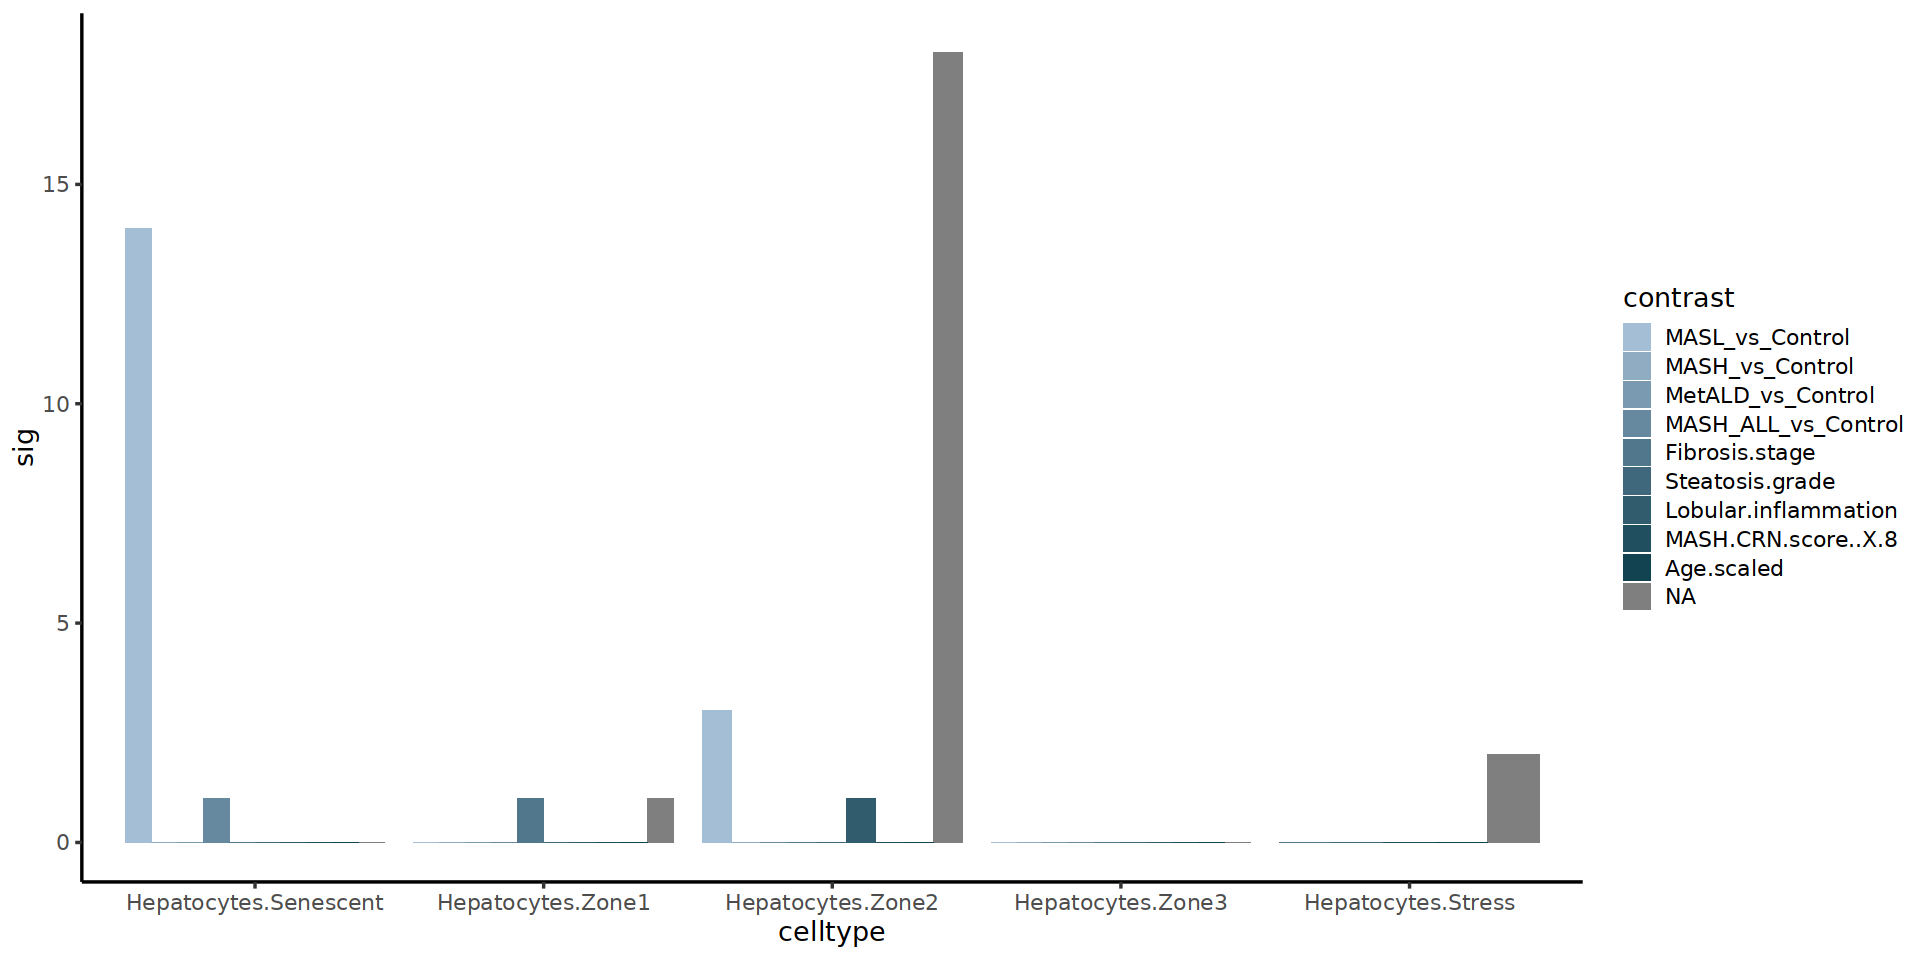

In [121]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [122]:
contrasts  <- c('BMI','BMI.scaled')


# Define the DESeq2 formula
deseq.base.formula <- '~ Fibrosis.stage + Age.scaled + batch + Gender'

In [123]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("Subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (contrast in contrasts) {
        contrast.use <- contrast
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        samples <- meta_cell %>%  
                   pull(donor)
        
        if(length(samples) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell.use[[contrast.use]])) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2 with a check for full rank
            tryCatch({
                deseq.formula <- as.formula(paste0(deseq.base.formula,'+',contrast.use))
                
                
                dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
                
                # DESeq analysis
                dds <- DESeq(dds)
                dds.results <- results(dds)
                
                # Write DESeq results to file
                write.table(dds.results, 
                    file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                    sep = '\t', quote = FALSE)
                
                dds.results <- na.omit(dds.results[order(dds.results$padj), ])
                
                # Write DESeq results to file
                write.table(dds.results, 
                            file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                            sep = '\t', quote = FALSE)
                
                # Collect summary statistics
                deseq.stats.tmp <- data.frame(
                    celltype = cell.use,
                    contrast = contrast.use,
                    up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                    down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                    up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                    down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)
                
                             # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               contrast.use, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")

            }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}


[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

Subsetting metadata accordingly - Check that value is equal to above: 34

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

Subsetting metadata accordingly - Check that value is equal to above: 10

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

Subsetting metadata accordingly - Check that value is equal to above: 33

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

Subsetting metadata accordingly - Check that value is equal to above: 27

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

Subsetting metadata accordingly - Check that value is equal to above: 54

  - BMI

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-disper

In [124]:
deseq.stats <- distinct(deseq.stats)
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [125]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0


In [126]:
deseq.stats2 <- deseq.stats

In [127]:
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'MASH.CRN.score..X.8', 'Age.scaled', 'BMI.scaled'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

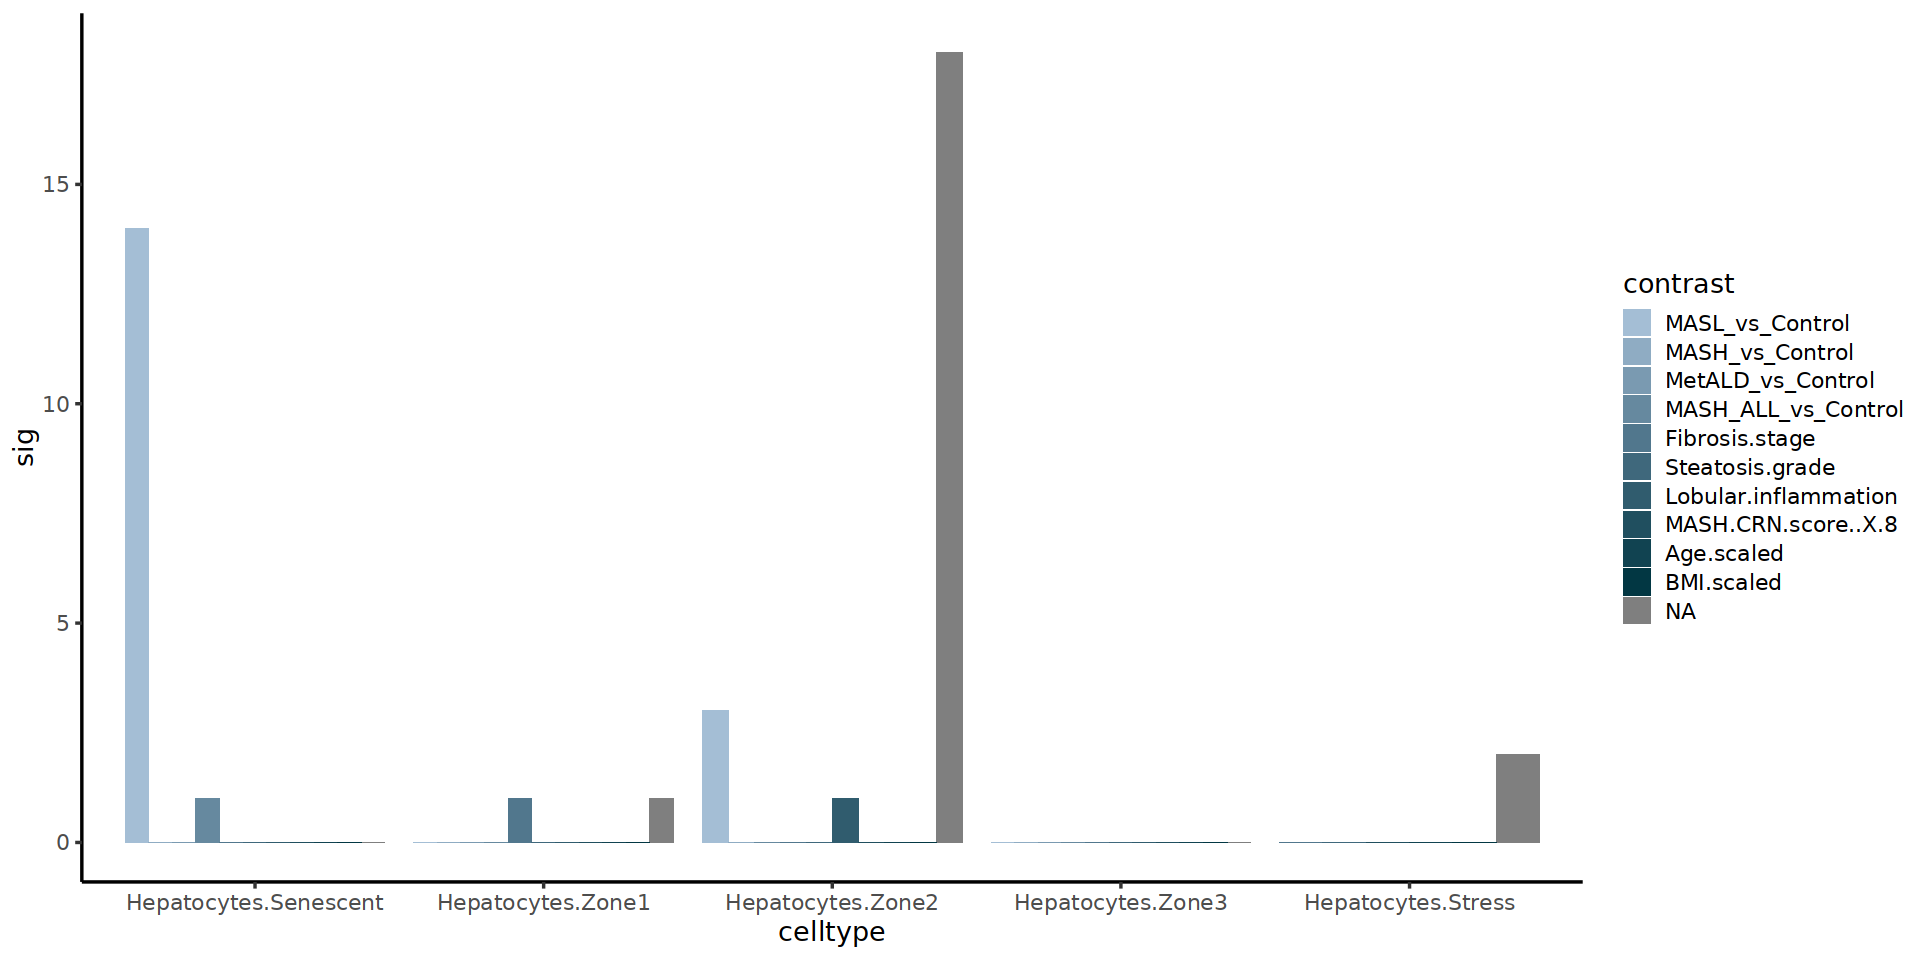

In [128]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [129]:
write.table(deseq.stats, paste0(outdir, '240920_WE_deseq_summary_add_contrasts_v2.tsv'),
           col.names=T, row.names=T, quote=F, sep='\t')

In [130]:
# List your contrasts  
conditions.1 = c("Low_Fibrosis", "High_Fibrosis") # disease
conditions.2 = c("Control", "Control") # control
contrasts = c(paste0(conditions.1, "_vs_", conditions.2))

# Write your formual
deseq.formula <- as.formula('~ Age.scaled + BMI.scaled + batch + Gender + condition') # last variable is the testing variable

In [131]:
unique(meta$condition)

[1] "MASL"    "MASH"    "MetALD"  "Control"

In [132]:
seq_along(files)

[1] 1 2 3 4 5

In [133]:
#deseq.stats = NULL

for (i in seq_along(files)) {
    file.use = files[i]
    cell.use = cells[i]
    if(cell.use %in% c('Bulk')) {
        next
    }
    
    print(paste0("Analyzing: ", cell.use))
    raw_counts <- read.table(paste0(dir, file.use), header = TRUE, row.names = 1)
    # Remove low bc cells
    raw_counts <- raw_counts[colnames(raw_counts) %in% meta$donor_demux[meta[[cell.use]] > 10]]
    # Filter for only samples with any counts in the cell type rowSums(raw_counts == 0)
    raw_counts = raw_counts[, (colSums(raw_counts >= 0) > 0)]
    # Subset samples to make one feature with counts in every sample
    best.row <- raw_counts[which(rowSums(raw_counts!=0) == max(rowSums(raw_counts != 0))),][1,]
    raw_counts <- raw_counts[colnames(raw_counts) %in% colnames(best.row)[best.row != 0]]
    print(dim(raw_counts))
    
    message("Donors detectected with celltype: ", ncol(raw_counts))
    if(ncol(raw_counts) == 0) {
        next
    }
    meta_cell <- subset(meta, donor %in% colnames(raw_counts))
    rownames(meta_cell) = meta_cell$donor
    message("subsetting metadata accordingly - Check that value is equal to above: ", nrow(meta_cell))
    # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
    meta_cell <- meta_cell[match(colnames(raw_counts), rownames(meta_cell)), ]
    
    for (c.i in seq_along(contrasts)) {
        contrast.use = contrasts[c.i]
        condition.1 = conditions.1[c.i]
        condition.2 = conditions.2[c.i]
        message("  - ", contrast.use)

        # Create vectors of samples for each condition
        if (condition.1 == 'Low_Fibrosis') {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage <= 2) %>% 
                               pull(donor)
        } else {
            samples.condition.1 <- meta_cell %>% 
                               dplyr::filter(condition %in% c('MASH','MetALD') & Fibrosis.stage >= 3) %>% 
                               pull(donor)
        }
        samples.condition.2 <- meta_cell %>% 
                               dplyr::filter(condition %in% condition.2) %>% 
                               pull(donor)
        
        if(length(samples.condition.1) < 3) {
            next
        }
        if(length(samples.condition.2) < 3) {
            next
        }
        
        # Subset meta_cell for the current contrast
        meta_cell.use <- meta_cell %>% 
                     dplyr::filter(donor %in% c(samples.condition.1, samples.condition.2)) 
        rownames(meta_cell.use) <- meta_cell.use$donor
        
        # Subset raw_counts for the donors in meta_cell
        raw_counts_subset <- raw_counts[, colnames(raw_counts) %in% rownames(meta_cell.use)]

        # Ensure that the column names of raw_counts are in the same order as the library identifiers in meta_cell
        meta_cell.use <- meta_cell.use[match(colnames(raw_counts_subset), rownames(meta_cell.use)), ]
        
        # Check if enough samples are present for both conditions
        if (length(unique(meta_cell$condition)) >= 2) {
            deseq.stats.tmp <- data.frame()
            
            # Light pre-filtering
            counts_filtered <- raw_counts_subset[rowSums(raw_counts_subset) >= 10,]

            # Run DESeq2
            tryCatch({
            dds <- DESeqDataSetFromMatrix(countData = round(counts_filtered),
                                              colData = meta_cell.use, 
                                              design = deseq.formula)
            dds$condition <- relevel(dds$condition, ref = condition.2)
            dds <- DESeq(dds)
            dds.results <- results(dds)
                
            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
                
            dds.results <- na.omit(dds.results[order(dds.results$padj), ])

            # Write DESeq results to file
            write.table(dds.results, 
                        file = paste0(outdir, cell.use, "_", contrast.use, ".dds.res"), 
                        sep = '\t', quote = FALSE)
            
            # Collect summary statistics
            deseq.stats.tmp <- data.frame(
                celltype = cell.use,
                contrast = contrast.use,
                up_pval = sum(dds.results$log2FoldChange > 0 & dds.results$pvalue < 0.05),
                down_pval = sum(dds.results$log2FoldChange < 0 & dds.results$pvalue < 0.05),
                up_padj = sum(dds.results$log2FoldChange > 0 & dds.results$padj < 0.1),
                down_padj = sum(dds.results$log2FoldChange < 0 & dds.results$padj < 0.1))
                deseq.stats <- rbind(deseq.stats, deseq.stats.tmp)

                           # Make Volcano plot - Padj
                            res = as.data.frame(dds.results)
                            res$SYMBOL = rownames(res)
                            res = res %>%
                            dplyr::filter(!is.na(SYMBOL)) %>%
                            dplyr::filter(padj < 0.1) %>%
                            dplyr::group_by(sign(log2FoldChange)) %>%
                            dplyr::mutate(rank = abs(log2FoldChange) * -log10(padj)) %>%
                            dplyr::top_n(50, rank) %>%
                            dplyr::mutate(delabel = SYMBOL) %>%
                            ungroup() %>%
                            dplyr::select(delabel, SYMBOL) %>%
                            right_join(res) %>%
                            dplyr::mutate(delabel = if_else(is.na(delabel), "", as.character(delabel))) 

                            # Add a new column for color based on significance and direction
                            res$changes <- ifelse(res$log2FoldChange > 0 & res$padj < 0.1, "Up-regulated",
                                                ifelse(res$log2FoldChange < 0 & res$padj < 0.1, "Down-regulated", "NS"))
                            # Get the number of upregulated and downregulated genes
                            n_up <- sum(res$changes == "Up-regulated")
                            n_down <- sum(res$changes == "Down-regulated")

                            # Modify log2FoldChange values to be max x
                            res$log2FoldChange[res$log2FoldChange > 10] <- 10
                            res$log2FoldChange[res$log2FoldChange < -10] <- -10
                            # Modify padj values to be max x 
                            res$padj[res$padj < 10^-200] <- 10^-200
                    
                            plot = ggplot(res, aes(x=log2FoldChange, y=-log10(padj), label=delabel, color=changes)) +
                                theme_bw() +
                                labs(y="-log10(padj)", x="log2FoldChange", 
                                   title=paste(cell.use, " - ",
                                               condition.1, "Vs", condition.2, "\n",
                                              "Up: ", n_up, "-",
                                               "Down: ", n_down)) +
                                geom_point() +
                                scale_color_manual(values=c("blue", "grey", "red")) + 
                                theme(axis.text=element_text(size=16), axis.title=element_text(size=16, face="bold"),
                                    axis.text.x=element_text(), plot.title=element_text(size=18, face="bold", hjust=0.5)) +
                                scale_x_continuous(breaks=c(-10, -5, 0, 5, 10),
                                            labels=c("< -10", "-5", "0", "5", "> 10"), lim = c(-10, 10))+
                                scale_y_continuous(breaks=c(0, 20, 40, 60, 80, 100, 200),
                                            labels=c("0", "20", "40", "60", "80", "100", ">200"))+
                                geom_text_repel(label=res$delabel, size=3.5, max.overlaps=10,
                                              point.padding=0, min.segment.length=0,
                                              max.time=20, max.iter=1e5, box.padding=0.3)
                    
                            ggsave(filename = paste0(outdir, cell.use, "_", contrast.use, ".volcanoPlot.pdf"),
                                   height = 10, width = 10,
                                   plot = plot, device = "pdf")
                #when it throws an error, the following block catches the error
                }, error = function(e) {
                message(paste0("Skipping contrast ", contrast.use, ": ", e$message))
            })
        } else {
            message("Not enough samples for contrast: ", contrast.use)
        }
    }
}

[1] "Analyzing: Hepatocytes.Senescent"
[1] 329833     34


Donors detectected with celltype: 34

subsetting metadata accordingly - Check that value is equal to above: 34

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Stress"
[1] 329833     10


Donors detectected with celltype: 10

subsetting metadata accordingly - Check that value is equal to above: 10

  - Low_Fibrosis_vs_Control

  - High_Fibrosis_vs_Control



[1] "Analyzing: Hepatocytes.Zone1"
[1] 329833     33


Donors detectected with celltype: 33

subsetting metadata accordingly - Check that value is equal to above: 33

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone2"
[1] 329833     27


Donors detectected with celltype: 27

subsetting metadata accordingly - Check that value is equal to above: 27

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

[1] "Analyzing: Hepatocytes.Zone3"
[1] 329833     54


Donors detectected with celltype: 54

subsetting metadata accordingly - Check that value is equal to above: 54

  - Low_Fibrosis_vs_Control

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion es

In [134]:
deseq.stats

celltype,contrast,up_pval,down_pval,up_padj,down_padj
<chr>,<chr>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,MASL_vs_Control,0,113,0,14
Hepatocytes.Senescent,MASH_vs_Control,11,35,0,0
Hepatocytes.Senescent,MetALD_vs_Control,36,57,0,0
Hepatocytes.Zone1,MASL_vs_Control,23,44,0,0
Hepatocytes.Zone1,MASH_vs_Control,1,227,0,0
Hepatocytes.Zone1,MetALD_vs_Control,10,101,0,0
Hepatocytes.Zone2,MASL_vs_Control,34,2,3,0
Hepatocytes.Zone2,MASH_vs_Control,25,29,0,0
Hepatocytes.Zone3,MASL_vs_Control,485,351,0,0


In [135]:
outdir

[1] "/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/LiverUnionPeak_mtx/Hep_Subtypes/"

In [136]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0,0,2
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0,0,NA
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0,1,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0,NA,NA


In [137]:
mutate(deseq.stats, sig = up_padj + down_padj) %>%
    select(celltype, contrast, sig) %>%
    pivot_wider(names_from = contrast, values_from = sig)

celltype,MASL_vs_Control,MASH_vs_Control,MetALD_vs_Control,MASH_ALL_vs_Control,Fibrosis.stage,Steatosis.grade,Lobular.inflammation,MASH.CRN.score..X.8,Ballooning,Age,Age.scaled,BMI,BMI.scaled,Low_Fibrosis_vs_Control,High_Fibrosis_vs_Control
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Hepatocytes.Senescent,14,0,0,1,0,0,0,0,NA,0,0,0,0,0,2
Hepatocytes.Zone1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,2
Hepatocytes.Zone2,3,0,NA,0,0,0,1,0,18,0,0,0,0,0,NA
Hepatocytes.Zone3,0,0,0,0,0,0,0,0,NA,0,0,0,0,1,0
Hepatocytes.Stress,NA,NA,NA,NA,0,0,NA,0,2,0,0,0,0,NA,NA


In [143]:
deseq.stats2 <- deseq.stats

In [153]:
unique(deseq.stats$contrast)

[1] "MASL_vs_Control"          "MASH_vs_Control"         
 [3] "MetALD_vs_Control"        "MASH_ALL_vs_Control"     
 [5] "Fibrosis.stage"           "Steatosis.grade"         
 [7] "Lobular.inflammation"     "MASH.CRN.score..X.8"     
 [9] "Ballooning"               "Age"                     
[11] "Age.scaled"               "BMI"                     
[13] "BMI.scaled"               "Low_Fibrosis_vs_Control" 
[15] "High_Fibrosis_vs_Control"

In [154]:
deseq.stats2 <- filter(deseq.stats2, contrast != 'BMI' & contrast != 'Age' & contrast != 'Ballooning' & contrast != 'MASH.CRN.score..X.8')
deseq.stats2$contrast <- factor(deseq.stats2$contrast, levels = c('MASL_vs_Control','MASH_vs_Control','MetALD_vs_Control',"MASH_ALL_vs_Control",'Fibrosis.stage',
                                    'Steatosis.grade', 'Lobular.inflammation', 'Age.scaled', 'BMI.scaled','Low_Fibrosis_vs_Control','High_Fibrosis_vs_Control'))
deseq.stats2$celltype <- factor(deseq.stats2$celltype, levels = unique(deseq.stats2$celltype))    

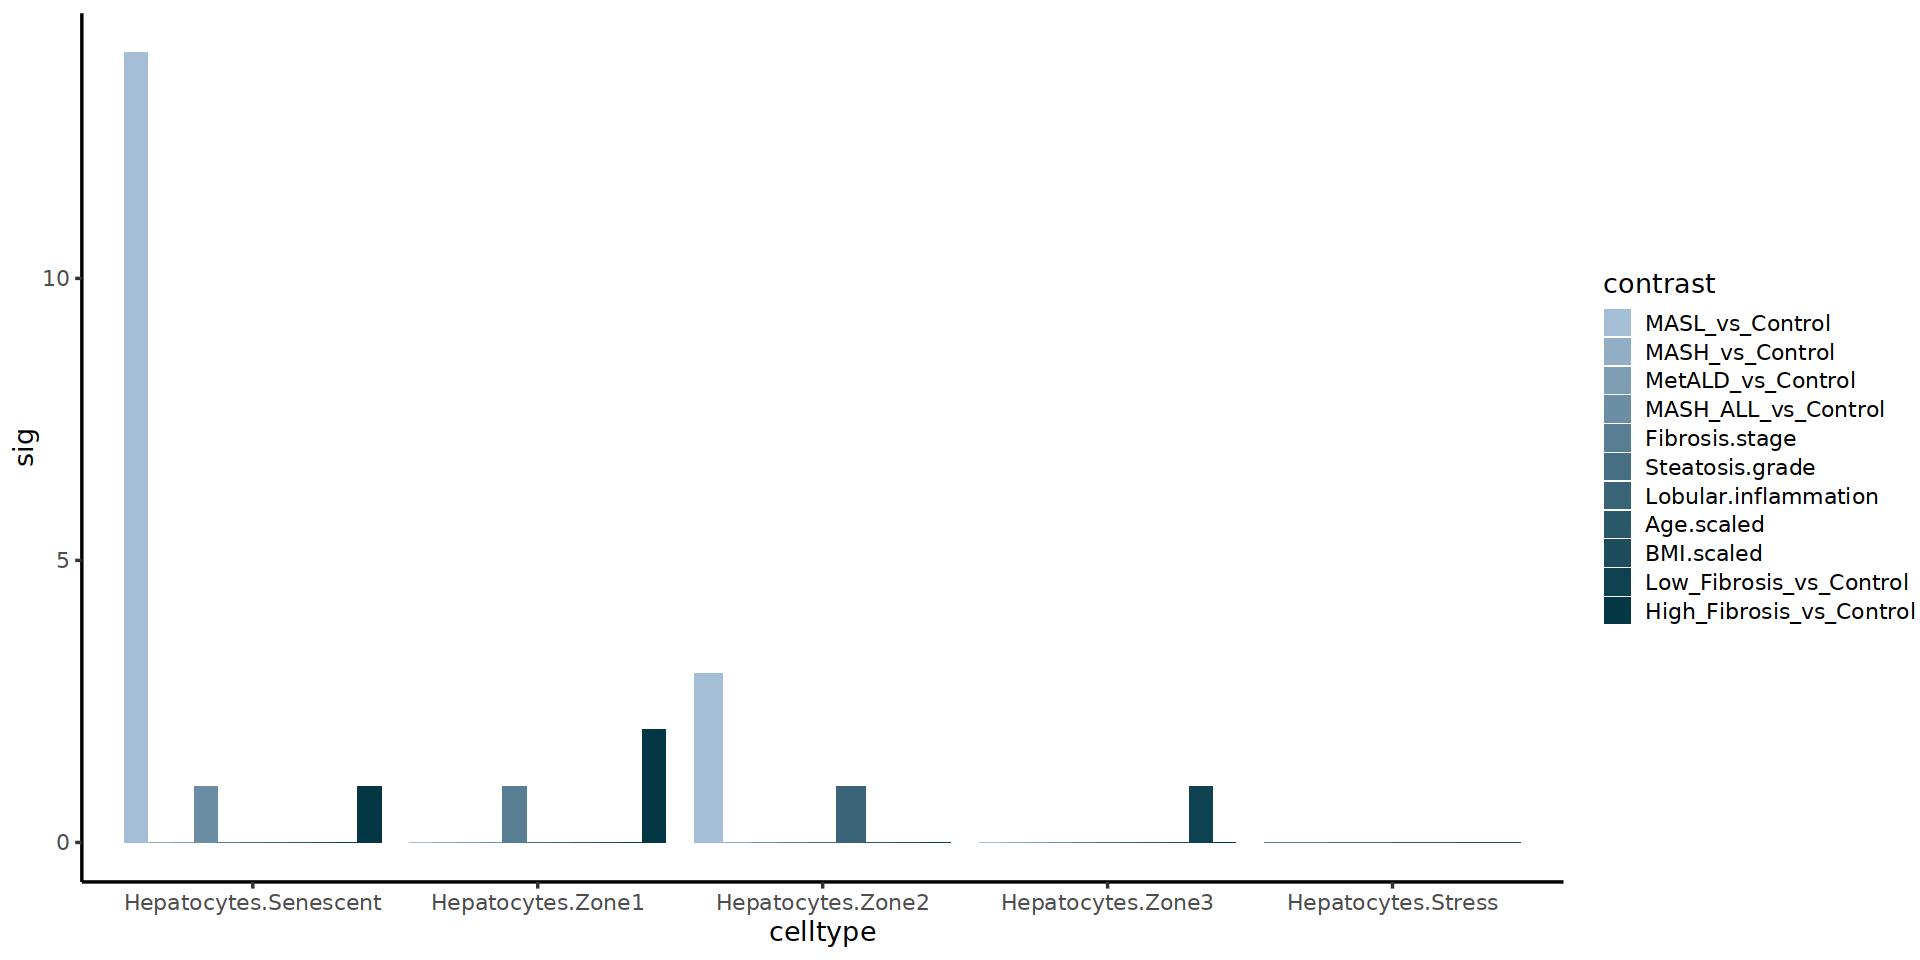

In [155]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_pval, -down_pval) %>%
    pivot_longer(c(up_padj, down_padj), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

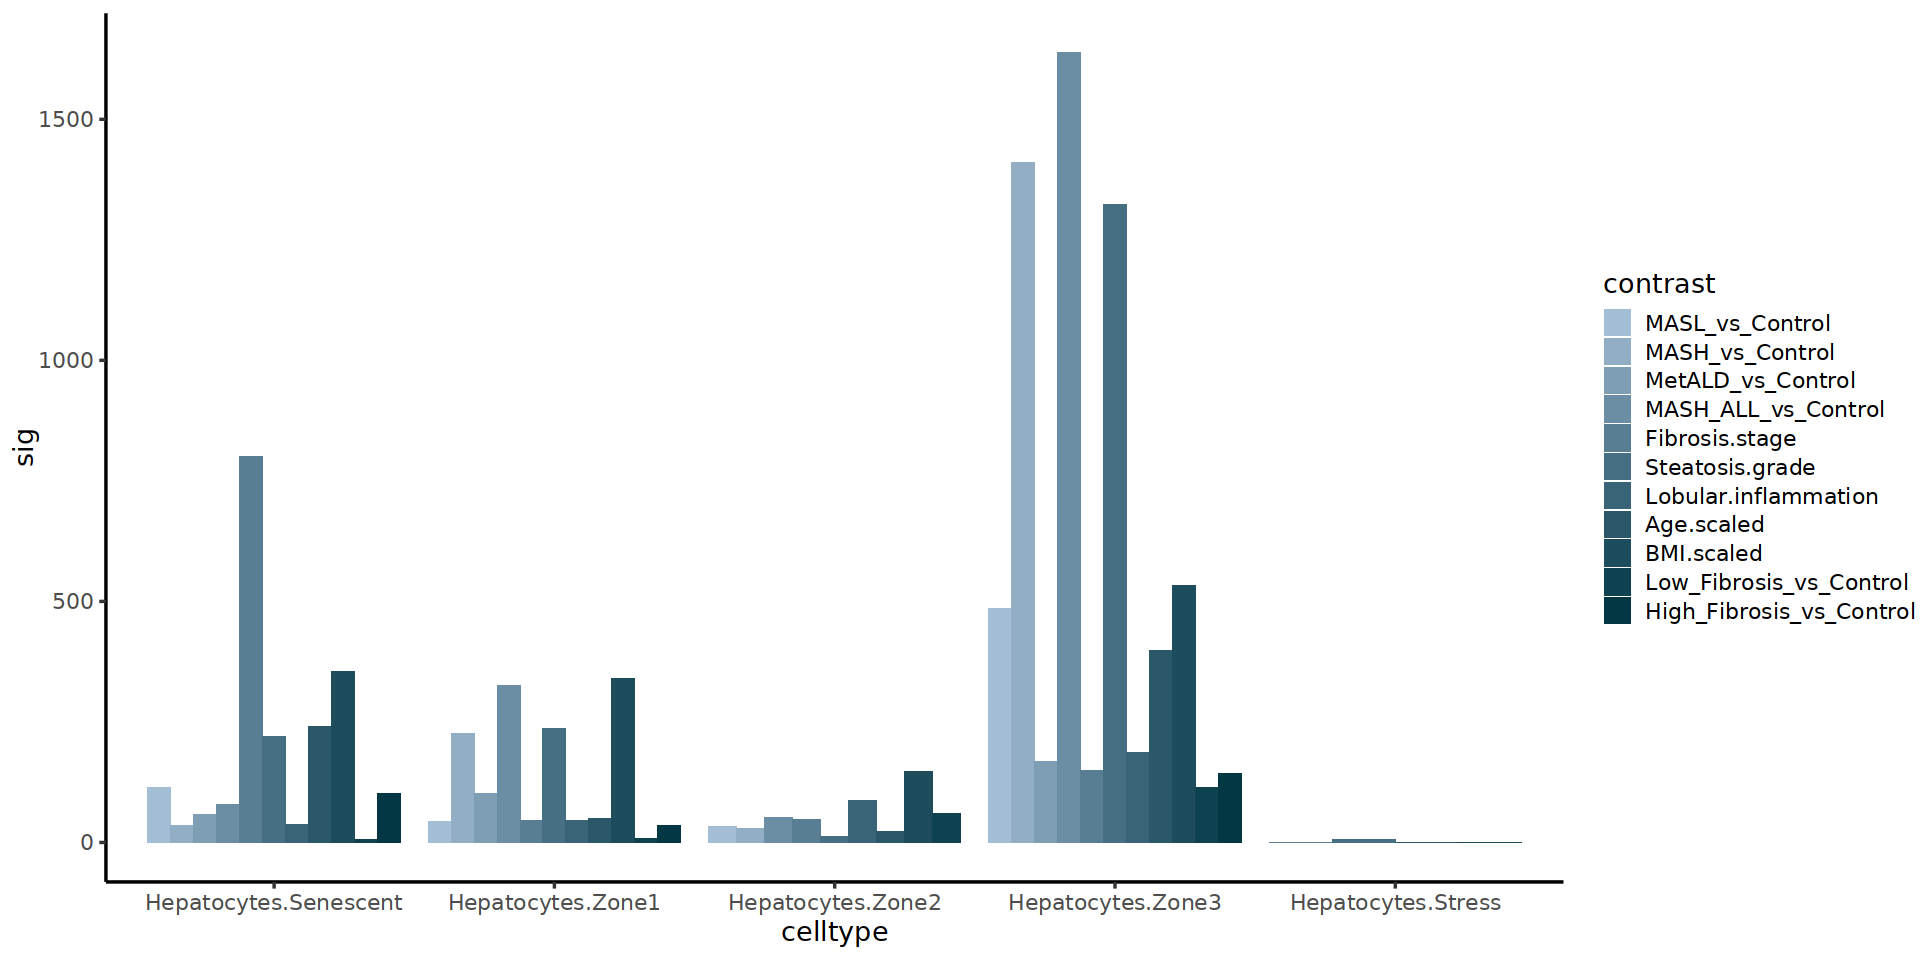

In [156]:
library(nationalparkcolors)

options(repr.plot.width=16, repr.plot.height=8)

ggplot(select(deseq.stats2, -up_padj, -down_padj) %>%
    pivot_longer(c(up_pval, down_pval), values_to = 'sig',names_to = 'direction'),
       aes(x=celltype, fill=contrast, y=sig)) + geom_col(position = 'dodge') +
    theme_classic(base_size=16) + scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(deseq.stats2$contrast))))

In [159]:
cell.use
file.use

[1] "Hepatocytes.Zone3"

[1] "Hepatocytes.Zone3_counts_spec_subset.tsv"

In [167]:
contrast.use

[1] "High_Fibrosis_vs_Control"

In [168]:
atac.res <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/250131_Hepatocyte_Subtype_DESeq/ATAC/Hepatocytes.Zone3_High_Fibrosis_vs_Control.dds.res', header=T, sep='\t')
atac.res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr11-123590601-123590901,12.368631,3.440666,0.3655128,9.413258,4.809938e-21,1.400188e-15
chr8-138582657-138582957,6.713899,3.793516,0.4378056,8.664842,4.521400e-18,6.580966e-13
chr6-47204315-47204615,4.982749,3.439157,0.4033618,8.526233,1.511905e-17,1.467066e-12
chr4-74632616-74632916,3.405790,3.336520,0.3940919,8.466350,2.532022e-17,1.842698e-12
chr8-138569842-138570142,5.380002,3.776770,0.4515168,8.364628,6.030478e-17,3.510981e-12
chr4-180923510-180923810,2.920123,3.463421,0.4206918,8.232681,1.830698e-16,8.882029e-12
chr14-96192161-96192413,4.538282,3.113206,0.3803127,8.185910,2.702543e-16,1.123883e-11
chr11-130638689-130638989,6.438808,2.894545,0.3584284,8.075658,6.711365e-16,2.442123e-11
chr9-38434897-38435189,7.623051,2.801245,0.3535257,7.923737,2.304768e-15,7.454720e-11


In [172]:
data.frame(dds.results) %>% arrange(pvalue)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:65081188-65081488,1.0818790,5.771984,1.679099,3.437548,0.0005870065,0.9999998
chr4:6947721-6948021,0.4950142,-11.675593,3.533334,-3.304413,0.0009517561,0.9999998
chr17:7307248-7307548,1.0815953,4.799625,1.487041,3.227636,0.0012481788,0.9999998
chr1:16624163-16624362,1.0918525,4.538337,1.467956,3.091604,0.0019907838,0.9999998
chr13:27251427-27251727,1.3976362,4.312049,1.419364,3.038014,0.0023814276,0.9999998
chr16:56329956-56330256,1.0018707,4.952638,1.634718,3.029659,0.0024483032,0.9999998
chr17:50950654-50950954,1.2313743,4.423964,1.475975,2.997317,0.0027236773,0.9999998
chr2:215749340-215749640,1.5370702,4.298793,1.438049,2.989323,0.0027959608,0.9999998
chr4:153520626-153520926,0.6948113,5.719314,1.939749,2.948481,0.0031933953,0.9999998


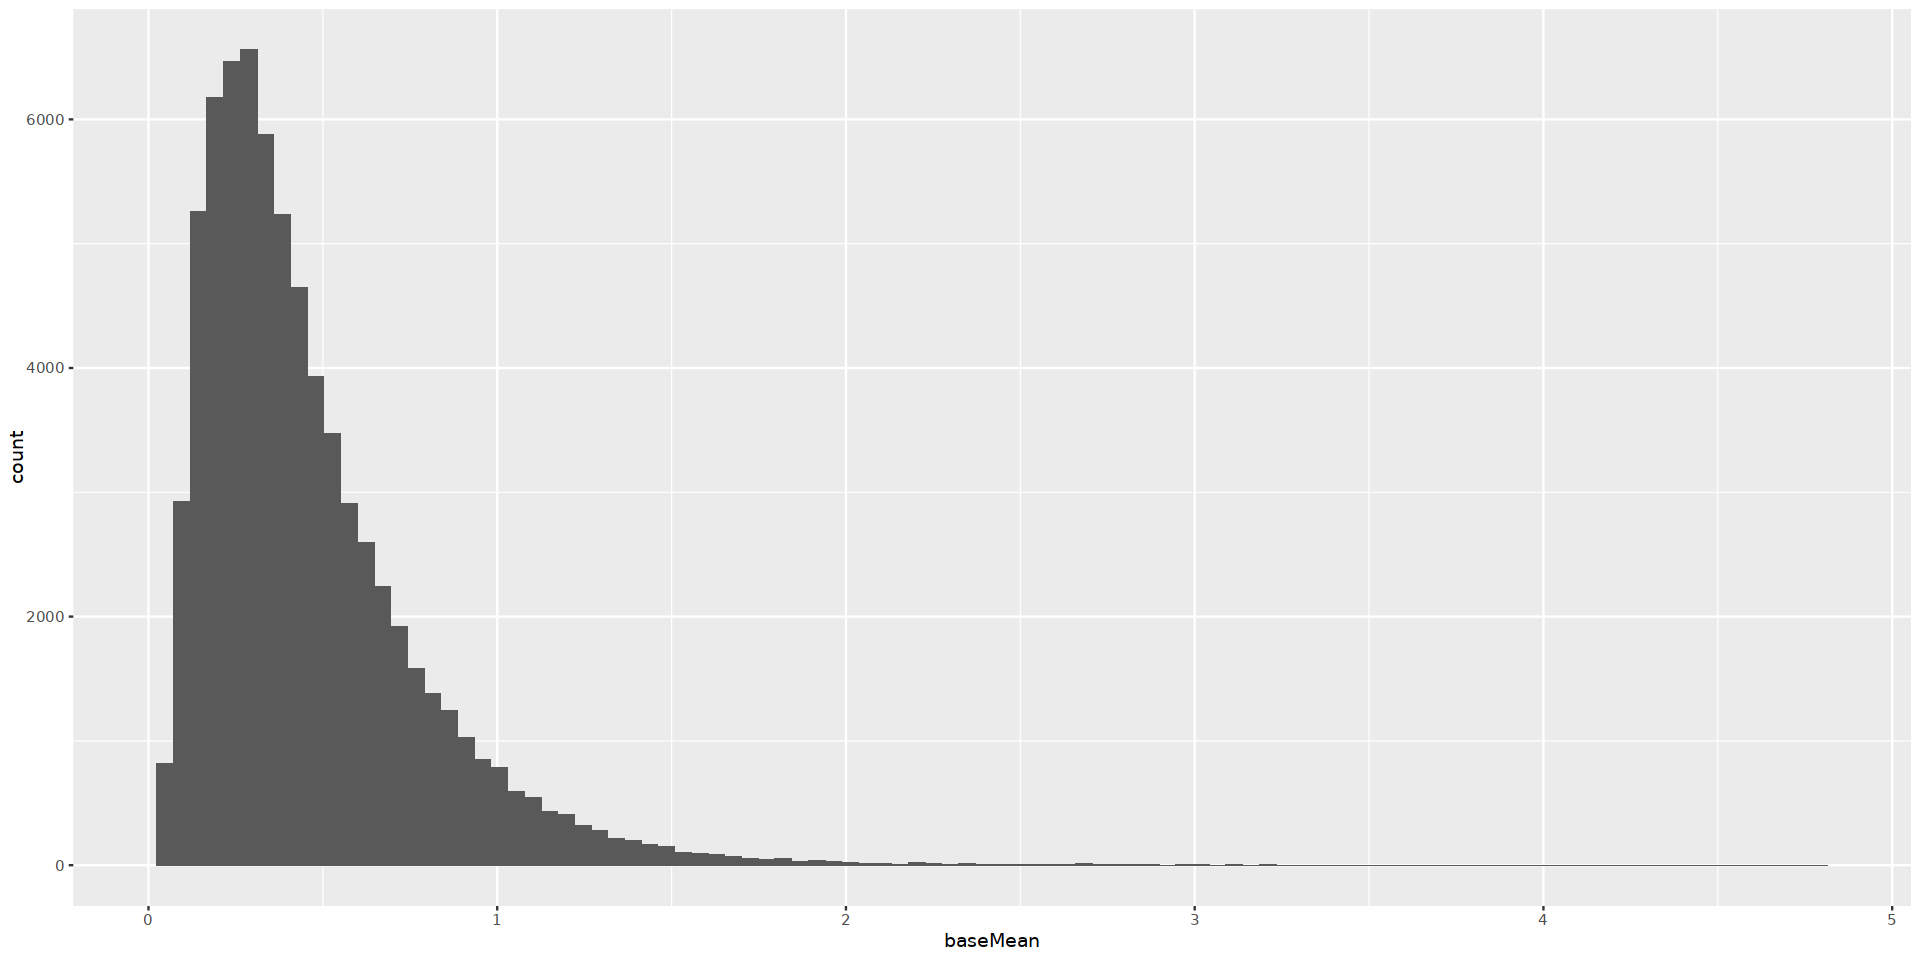

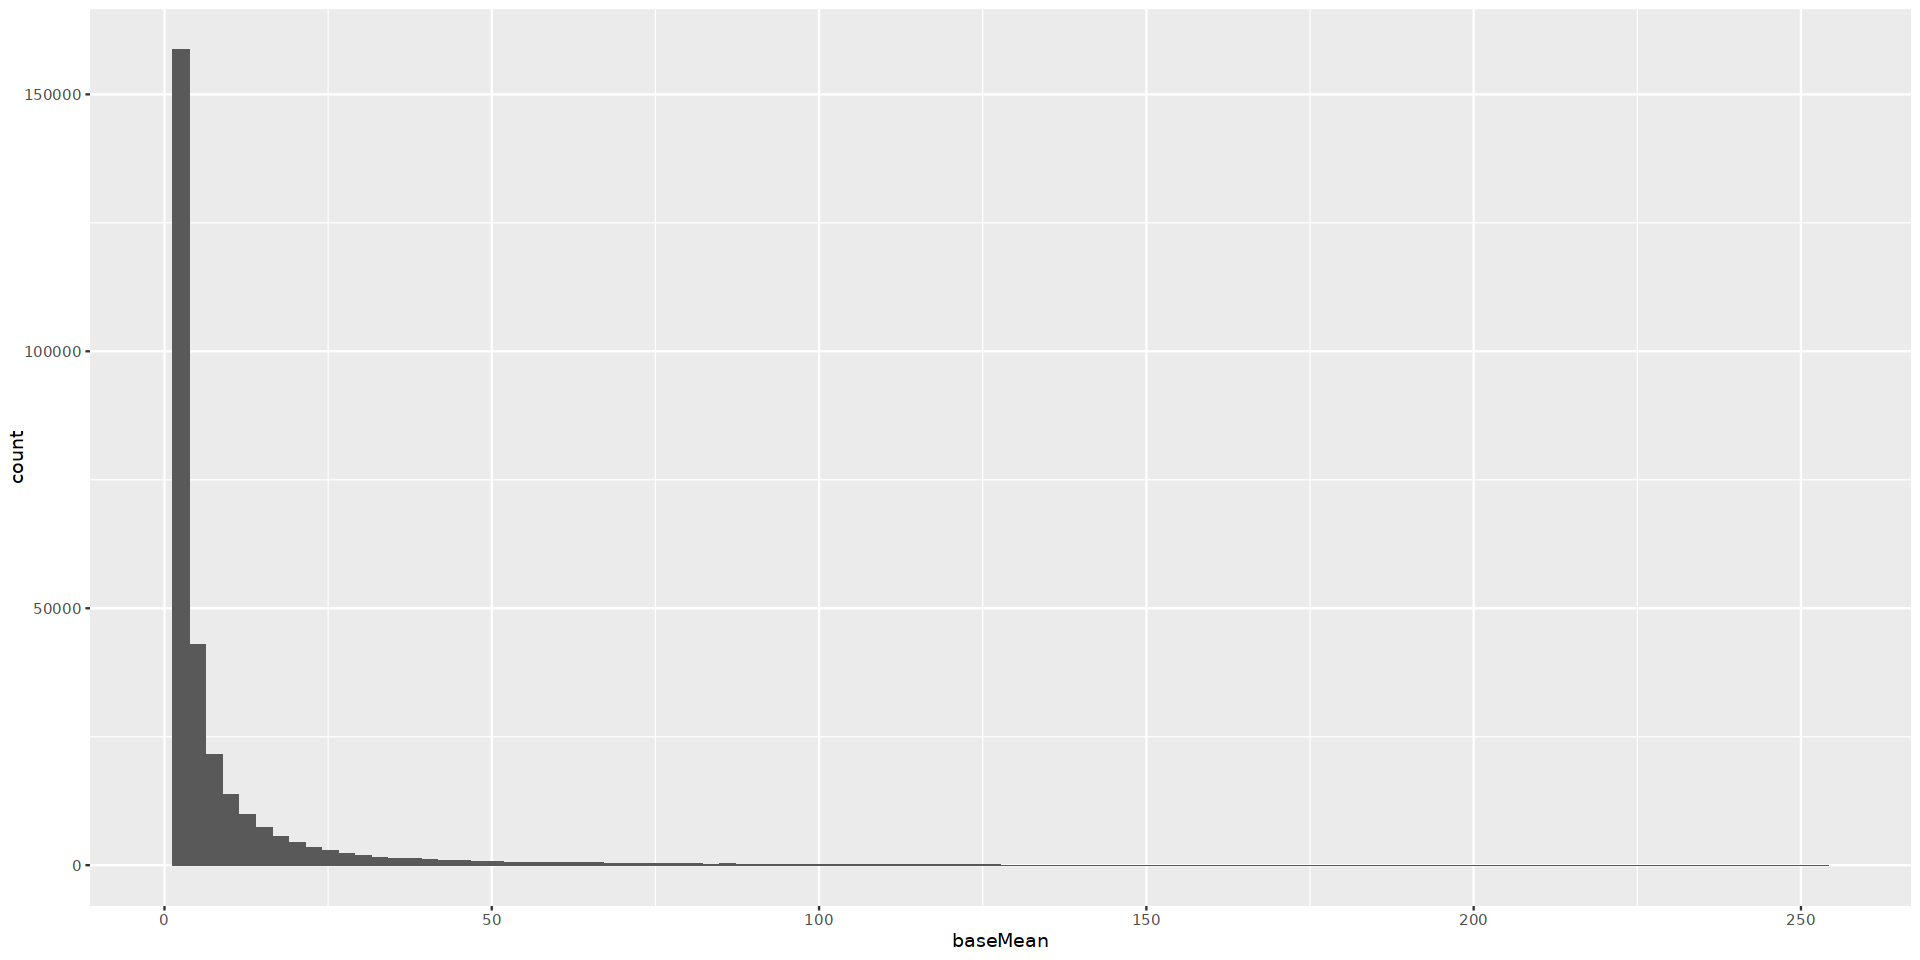

In [179]:
ggplot(data.frame(dds.results), aes(x=baseMean)) + geom_histogram(bins=100)
ggplot(atac.res, aes(x=baseMean)) + geom_histogram(bins=100)

In [175]:
atac.res[str_detect(rownames(atac.res), 'chr2-65081'),]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2-65081674-65081974,9.435878,0.4152449,0.2361270,1.7585660,0.07865126,0.4603033
chr2-65081188-65081488,23.686858,0.1196523,0.1853984,0.6453794,0.51868136,0.8667057
